<a href="https://colab.research.google.com/github/a-brhian/Design_Of_Experiments.pt/blob/main/04_Gradiente_conjugado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#-------------------------------------------
# INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNOLOGIA DO AMAZONAS
#
# CREATED BY: ALYSSON BRHIAN
# DATA: 15/06/2012
# VERSION OF R: 4.6.0
#
# GOAL: Gradiente Conjugado
#
#---------------------------------------------

#Gradiente Conjugado

O método do Gradiente Conjugado é um algoritmo usado para resolver sistemas de equações lineares muito grandes de forma rápida e eficiente, principalmente quando a matriz é simétrica e positiva definida. Na nossa disciplina, seria como poder encontrar o mínimo em uma superfície de resposta em um delineamento com vários fatores.

Esse método é importante porque evita cálculos desnecessários, economizando tempo e memória em comparação com métodos tradicionais. Na prática, ele deve ser usado quando o problema envolve muitos dados e resolver o sistema por métodos diretos seria muito lento ou exigiria muita memória. Assim, o Gradiente Conjugado oferece uma solução precisa e eficiente para problemas de grande escala.

Vamos encontrar o mínimo da função, otimizada na aula aula anterior:

$$f(\mathbf{x})=\boldsymbol{\beta}X^T$$

$$f(x_1,x_2)=0.960870-0.263137x_1+0.444454x_2+0.676087x_2^2$$

Dentro do quadrado experimental:

$$(x_1,x_2)\in[-\sqrt{2},\sqrt{2}]^2$$

A função pode ser escrita por meio do seguinte código:




In [2]:
f <- function(x){
  0.960870 -
  0.263137*x[1] +
  0.444454*x[2] +
  0.676087*x[2]^2
}

O seguinte passo consiste em calcular o gradiente da função:

$$\nabla f(x_1,x_2)
=
\begin{bmatrix}
\dfrac{\partial f}{\partial x_1}\\[6pt]
\dfrac{\partial f}{\partial x_2}
\end{bmatrix}
=
\begin{bmatrix}
−0.263137\\[6pt]
0.444454+1.352174x_2
\end{bmatrix}.
$$

Esse gradiente pode ser escrito como:




In [3]:
grad <- function(x)
{
  c(
   -0.263137,
    0.444454 + 1.352174*x[2]
  )
}

## Conhecendo o algortimo

Em resumo, termos que percorrer os seguintes passos:

1. **Definir a função objetivo:** estabelecer a função que será minimizada e os limites da região retangular.

2. **Escolher um ponto inicial:** selecionar um ponto dentro da região de busca.

3. **Calcular o gradiente:** determinar o gradiente da função no ponto atual.

4. **Definir a direção inicial:** utilizar o oposto do gradiente como direção de descida.

5. **Realizar a busca linear:** encontrar o melhor passo na direção escolhida, mantendo o ponto dentro da região retangular.

6. **Atualizar o gradiente:** calcular o gradiente no novo ponto obtido.

7. **Calcular o coeficiente conjugado:** determinar o fator que combina a direção anterior com o novo gradiente.

8. **Atualizar a direção de busca:** calcular a nova direção conjugada.

9. **Verificar o critério de parada:** encerrar o processo quando o gradiente for suficientemente pequeno ou quando o número máximo de iterações for atingido.

10. **Obter a solução:** considerar o último ponto calculado como a aproximação do mínimo da função na região retangular.

Vamos escolher um ponto onde acreditamos que possa estar o ponto mínimo:



[1] 0 0

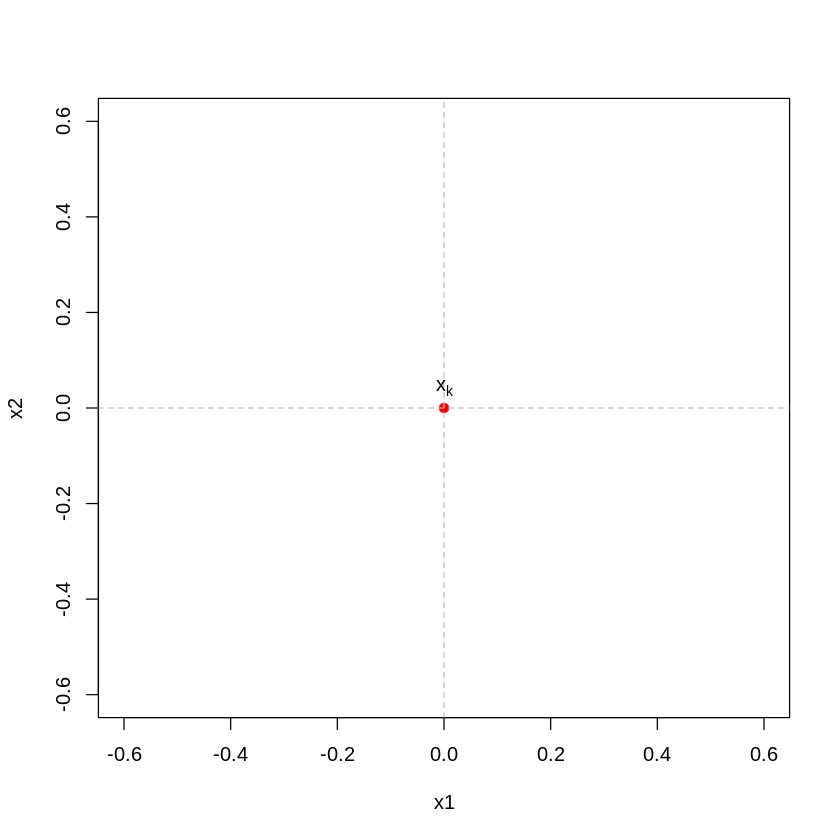

In [4]:
x <- c(0,0); x

plot(x[1], x[2],
     xlim = c(-1,1)*.6,
     ylim = c(-1,1)*.6,
     pch = 19, col = "red",
     xlab = "x1",
     ylab = "x2")

abline(h = 0, v = 0, lty = 2, col = "gray")

text(x[1],x[2],expression(x[k]),pos=3)

Calculemos o gradiente nesse ponto, isto é, a direção donde encontraremos um ponto de máximo:

[1] -0.263137  0.444454

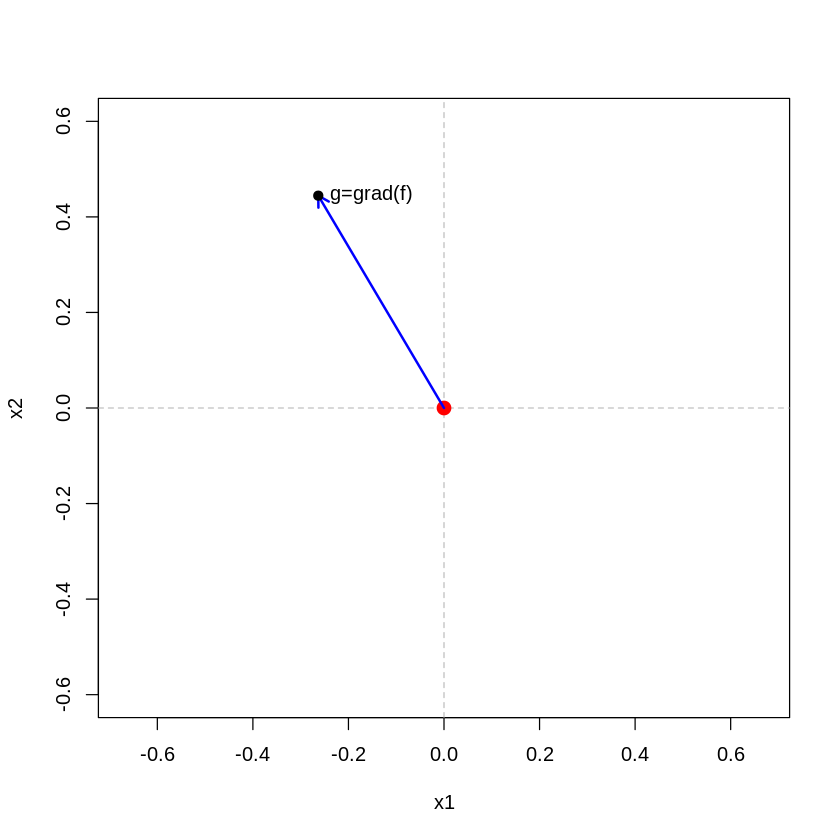

In [5]:
g <- grad(x); g

plot(0, 0,
     xlim = c(-1, 1)*.6,
     ylim = c(-1, 1)*.6,
     type = "n",
     xlab = "x1",
     ylab = "x2",
     asp = 1)

abline(h = 0, v = 0, lty = 2, col= "gray")

#Ponto atual
  points(
    x[1],
    x[2],

    pch = 19,
    col = "red",
    cex = 1.5
  )

arrows(0, 0,
       g[1], g[2],
       length = 0.1,
       lwd = 2,
       col="blue")

points(g[1], g[2], pch = 19)

text(g[1], g[2],
     labels = paste0("g=",expression(grad(f))),
     pos = 4)

Agora, como desejamos encontrar um ponto de mínimo, devemos seguir a direção oposta ao gradiente, pois ela representa a direção de maior descida da função:

[1]  0.263137 -0.444454

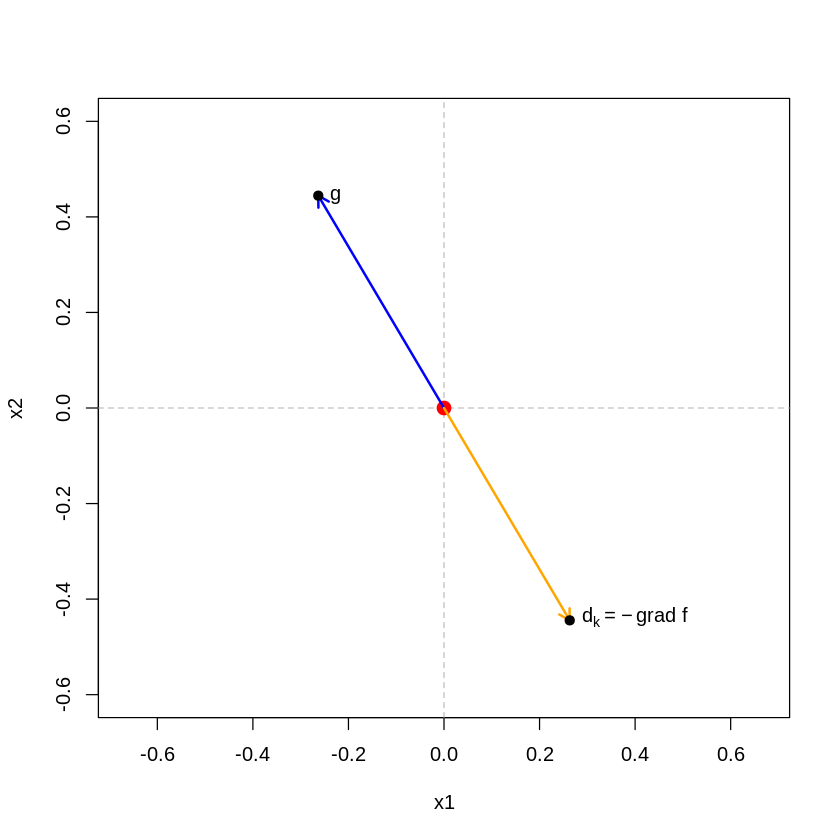

In [6]:
d <- -g; d

plot(0, 0,
     xlim = c(-1, 1)*.6,
     ylim = c(-1, 1)*.6,
     type = "n",
     xlab = "x1",
     ylab = "x2",
     asp = 1)

abline(h = 0, v = 0, lty = 2, col = "gray")

#Ponto atual
  points(
    x[1],
    x[2],

    pch = 19,
    col = "red",
    cex = 1.5
  )

#Gradiente
arrows(0, 0,
       g[1], g[2],
       length = 0.1,
       lwd = 2
       ,col="blue")

points(g[1], g[2], pch = 19)

text(g[1], g[2],
     labels = paste0("g"),
     pos = 4)

#Gradiente Negativo
arrows(0, 0,
       d[1], d[2],
       length = 0.1,
       lwd = 2,
       col="orange")

points(d[1], d[2], pch = 19)

text(d[1], d[2],
     labels = expression(d[k] == -"grad " * f),
     pos = 4)

Essa é a etapa da iteração que nos levará para o ponto de mínimo. Vamos fazer com que o nosso algoritmo dê o primeiro passo:

In [7]:
alpha <- 0.05

Vamos atualizar a posição:

[1]  0.01315685 -0.02222270

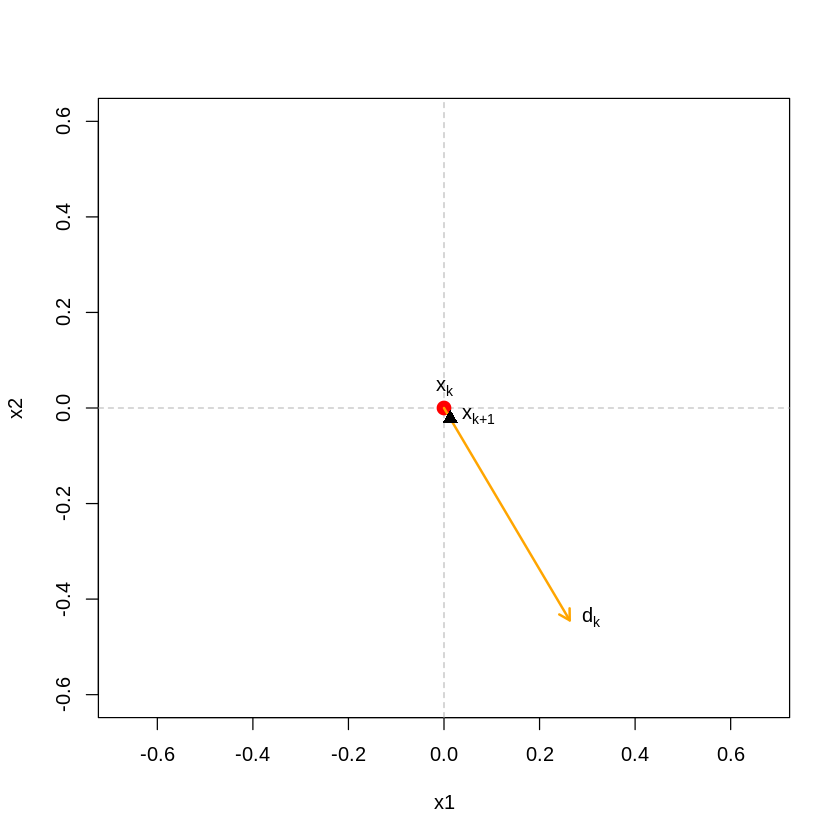

In [8]:
x_new <- x + alpha*d; x_new

x <- c(0,0)

plot(0,0,
     xlim=c(-1,1)*.6,
     ylim=c(-1,1)*.6,
     type="n",
     asp=1,
     xlab="x1",
     ylab="x2")

abline(h=0, v=0, lty=2, col = "gray")

# ponto inicial
points(x[1],x[2], pch=19, col="red", cex = 1.5)
text(x[1],x[2],expression(x[k]),pos=3)

# direção de descida
arrows(x[1],x[2],
       x[1]+d[1],
       x[2]+d[2],
       length=0.1,
       lwd=2,
      col="orange")

text(d[1],d[2],expression(d[k]),pos=4)

# novo ponto
points(x_new[1],x_new[2],pch=17,cex = 1.3)

text(x_new[1],x_new[2],expression(x[k+1]),pos=4)

Como $\mathbf{x}$ é limitada, temos que verificar se o ponto se encontra na região:

In [9]:
lim <- sqrt(2)

x_new[1] <- max(-lim,
                min(lim,x_new[1]))

x_new[2] <- max(-lim,
                min(lim,x_new[2]))

x_new

[1]  0.01315685 -0.02222270

Vamos calcular o novo gradiente nesse ponto:

In [10]:
g_new <- grad(x_new); g_new

[1] -0.263137  0.414405

E veremos o critério de parada:

In [11]:
if(sqrt(sum(g_new^2)) < 1e-8){
 break
}

Para avançarmos, vamos utilizar o valor anterior para verificar para onde termos que ir por meio do algoritmo de _Fletcher-Reeves_:

\begin{align}
\beta_{k+1}^{FR}
&=
\frac{g_{k+1}^{T}g_{k+1}}
     {g_k^{T}g_k}, \\
d_{k+1}
&=
-g_{k+1}
+
\beta_{k+1}^{FR} d_k.
\end{align}

em que:

- $\mathbf{g}_k$ é o gradiente da função na iteração atual;
- $\mathbf{g}_{k+1}$ é o gradiente da função na próxima iteração;
- $\mathbf{g}^{T}\mathbf{g}$ representa o produto interno do gradiente por ele mesmo, equivalente ao quadrado de sua norma.

O método de _Fletcher-Reeves_ calcula o coeficiente de conjugação ($\beta_k$), responsável por determinar quanto da direção de busca anterior será aproveitada na próxima iteração.

Após calcular ($\beta_k$), a nova direção de busca é atualizada por:

$$
\mathbf{d}_{k+1}
=
-\mathbf{g}_{k+1}
+
\beta_k\mathbf{d}_k,
$$

em que:

- $\mathbf{d}_k$ é a direção de busca da iteração anterior;
- $\mathbf{d}_{k+1}$ é a nova direção de busca.

Dessa forma, o método não reinicia a busca utilizando apenas a direção de maior descida (o oposto do gradiente). Em vez disso, ele combina a nova informação fornecida pelo gradiente com a direção anterior, produzindo direções conjugadas e acelerando a convergência para o ponto de mínimo.

### Interpretação do coeficiente $\beta_k$

Como $\beta_k$ é calculado pela razão entre duas normas ao quadrado, seu valor é sempre não negativo $\beta_k \geq 0$. Assim, podem ocorrer os seguintes casos:

- **$\beta_k = 0$:** indica que o novo gradiente é nulo, ou seja, o algoritmo atingiu um ponto estacionário (possivelmente um ponto de mínimo). Nesse caso, a direção anterior deixa de influenciar a busca.

- **$0 < \beta_k < 1$:** a nova direção de busca utiliza parte da direção anterior, mas com menor influência. Isso ocorre quando o gradiente diminuiu em relação à iteração anterior, indicando aproximação do mínimo.

- **$\beta_k > 0$:** significa que a direção anterior continua contribuindo para a nova direção de busca. Quanto maior o valor de $\beta_k$, maior será a influência da direção anterior na construção da nova direção conjugada.

Em problemas de otimização, é comum que, à medida que o algoritmo se aproxima do ponto de mínimo, o valor de $\beta_k$ diminua, reduzindo gradualmente a influência da direção anterior. Isso permite que o método ajuste a trajetória de busca de forma eficiente, evitando movimentos em zigue-zague e acelerando a convergência.

Com os valores já calculados, então $\beta^{FR}$ seria:

In [12]:
beta <- sum(g_new^2)/sum(g^2)

E a nova direção conjugada:

In [13]:
d <- -g_new + beta*d; d

[1]  0.5008186 -0.8158634

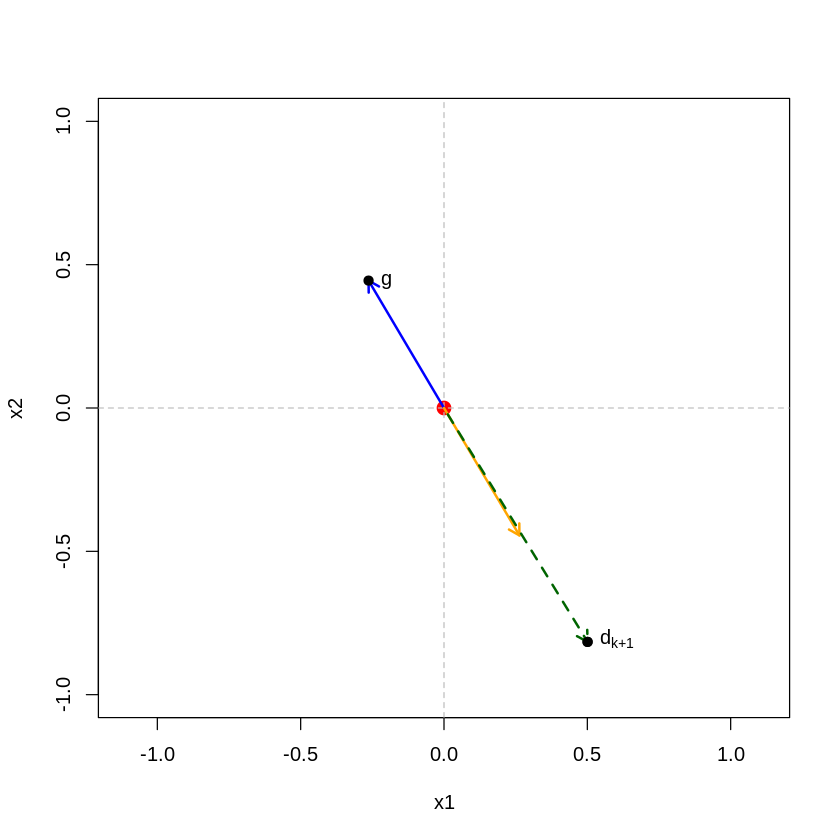

In [14]:
plot(0, 0,
     xlim = c(-1, 1),
     ylim = c(-1, 1),
     type = "n",
     xlab = "x1",
     ylab = "x2",
     asp = 1)

#Ponto atual
  points(
    x[1],
    x[2],

    pch = 19,
    col = "red",
    cex = 1.5
  )

abline(h = 0, v = 0, lty = 2, col = "gray")

#Gradiente
arrows(0, 0,
       g[1], g[2],
       length = 0.1,
       lwd = 2
       ,col="blue")

points(g[1], g[2], pch = 19)

text(g[1], g[2],
     labels = "g",
     pos = 4)

#Gradiente Negativo
arrows(0, 0,
       -g[1], -g[2],
       length = 0.1,
       lwd = 2,
       col="orange")

points(d[1], d[2], pch = 19)

#Direção Conjugada
arrows(x_new[1], x_new[2],
       d[1], d[2],
       length = 0.1,
       lty = 2,
       lwd = 2,
       col="darkgreen")

points(d[1], d[2], pch = 19)

text(d[1], d[2],
     labels = expression(d[k+1]),
     pos = 4)

onde em seguida é atribuido o novo ponto que repetirá esse algoritmo:

In [15]:
x <- x_new
g <- g_new

cat("x1 =",x[1],"e ")
cat("x2 =",x[2],"\n")
cat("f =",f(x),"\n")

x1 = 0.01315685 e x2 = -0.0222227 
f = 0.9478649 


## Repetindo o algoritmo

Agora vamos inserir o que aprendemos anteriormente dentro de uma repetiação.

O contorno da função no limite é:

In [16]:
lim <- sqrt(2)

x1_seq <- seq(-lim, lim, length.out = 100)

x2_seq <- seq(-lim, lim, length.out = 100)

z <- outer(
  x1_seq,
  x2_seq,
  Vectorize(function(x1,x2)
    f(c(x1,x2))
  )
)

Os valores iniciais e constantes são:

In [17]:
x <- c(-1,1)

g <- grad(x)

d <- -g

alpha <- 0.05

tol <- 1e-8

max_iter <- 40

O local para armazenar as iterações será:

In [18]:
historico <- data.frame(
  iter = numeric(),
  x1 = numeric(),
  x2 = numeric(),
  f = numeric(),
  grad_norm = numeric(),
  erro.g = numeric(),
  erro.x = numeric(),
  erro.f = numeric()
)

Onde o `erro.g` $=|\nabla f|$, `erro.x` $=|x_{i+1}-x_i|$ e o `erro.f` $=|f_{i+1}-f_i|$ .

A repetição (_loop_) desse algoritmo seria:

1 	

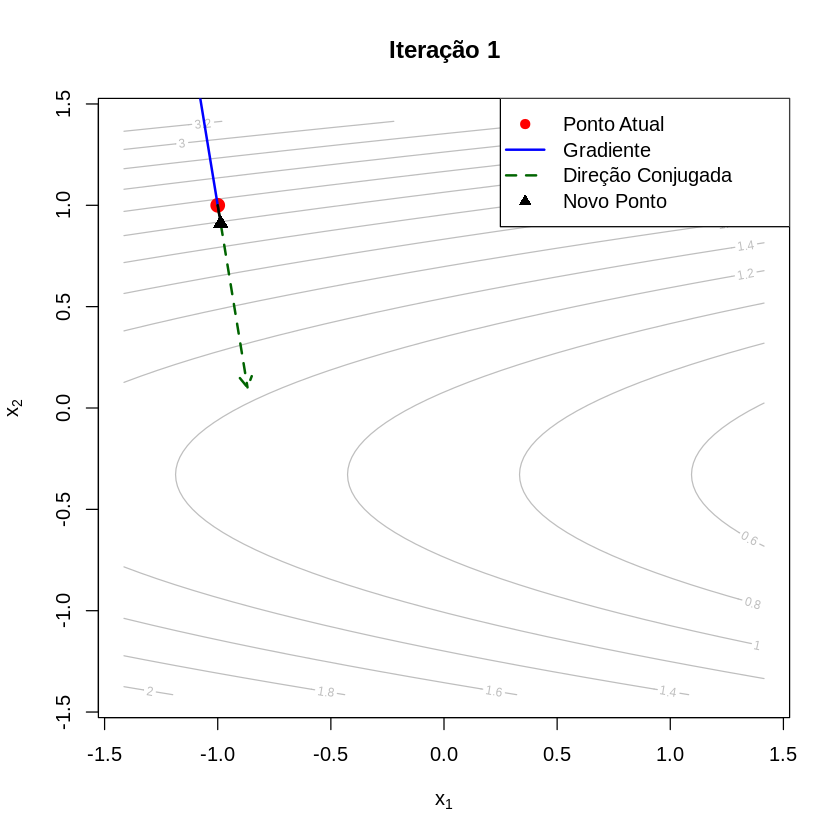

2 	

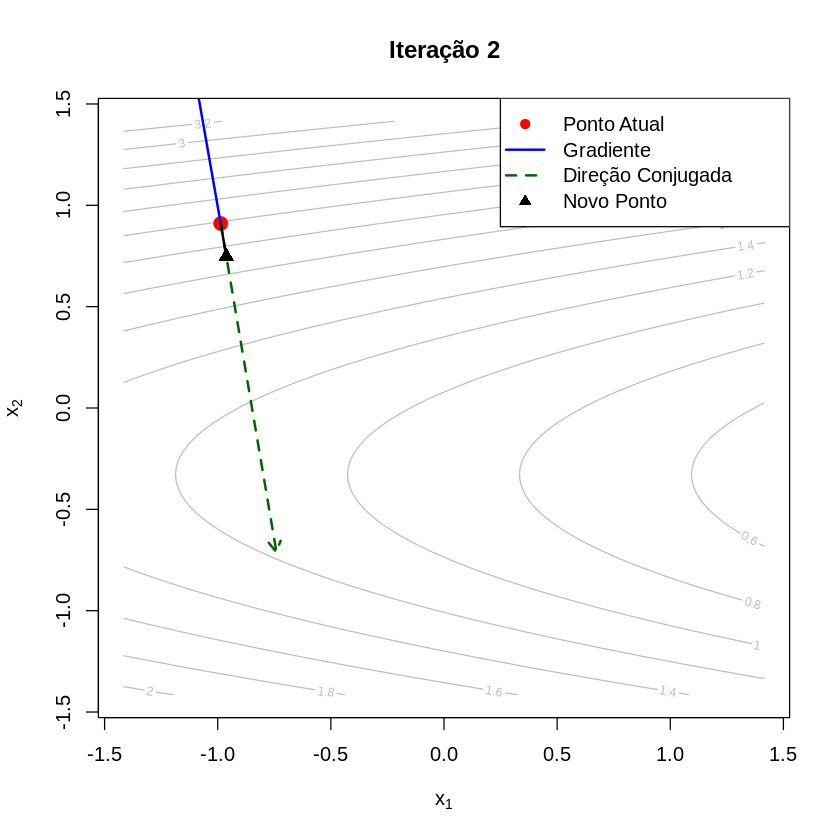

3 	

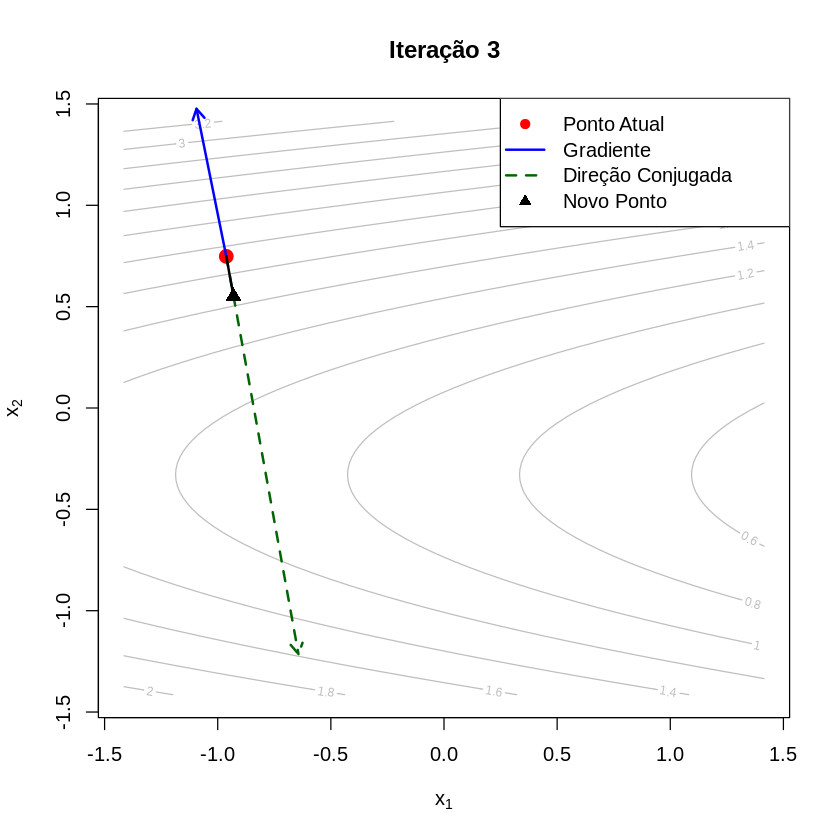

4 	

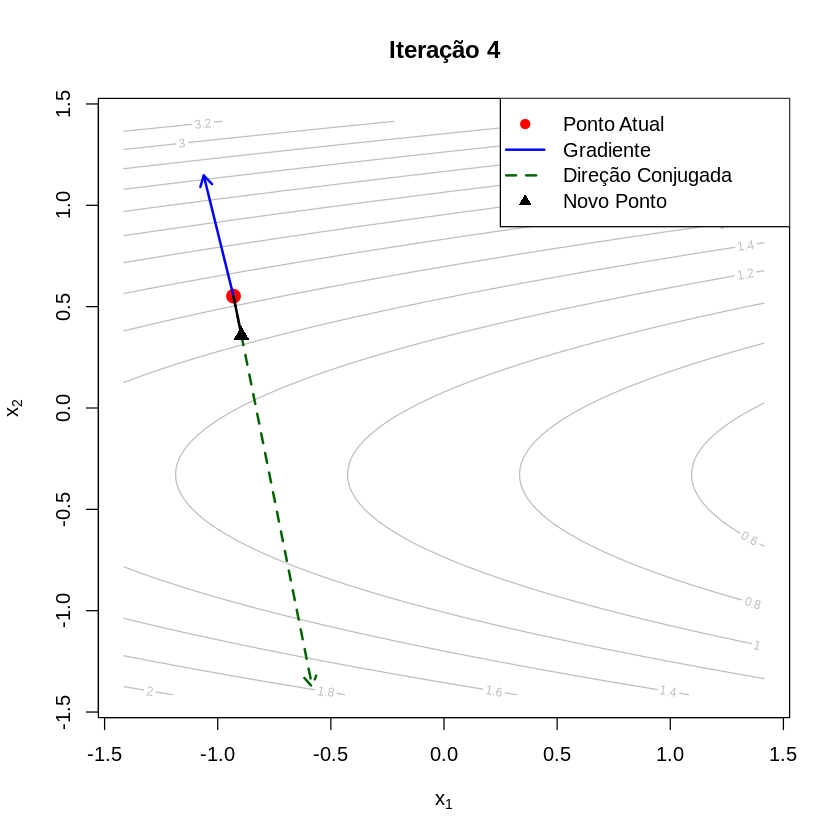

5 	

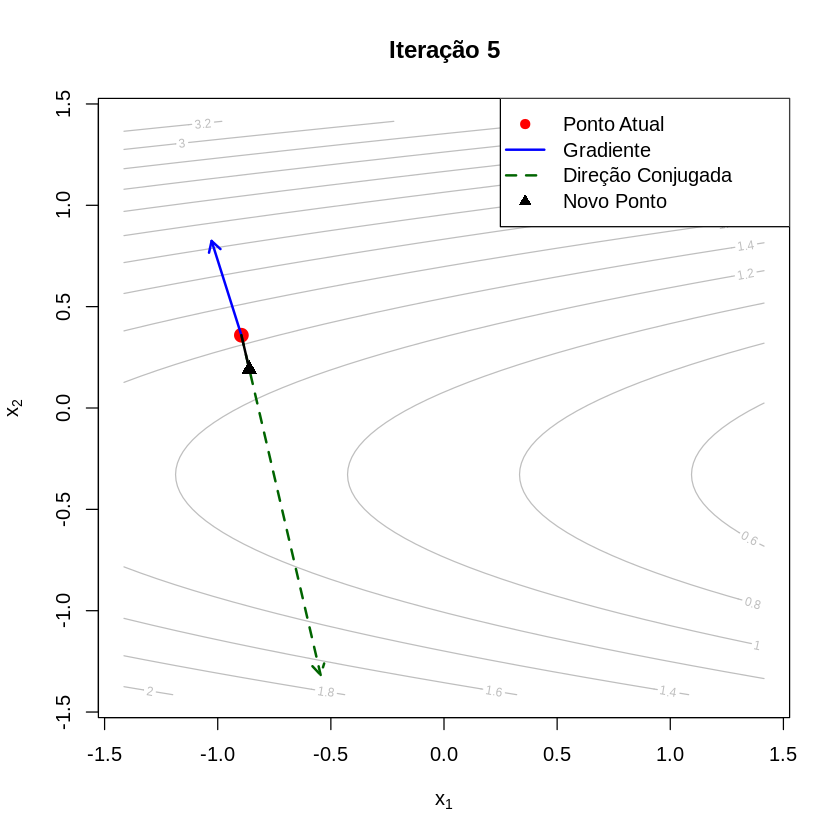

6 	

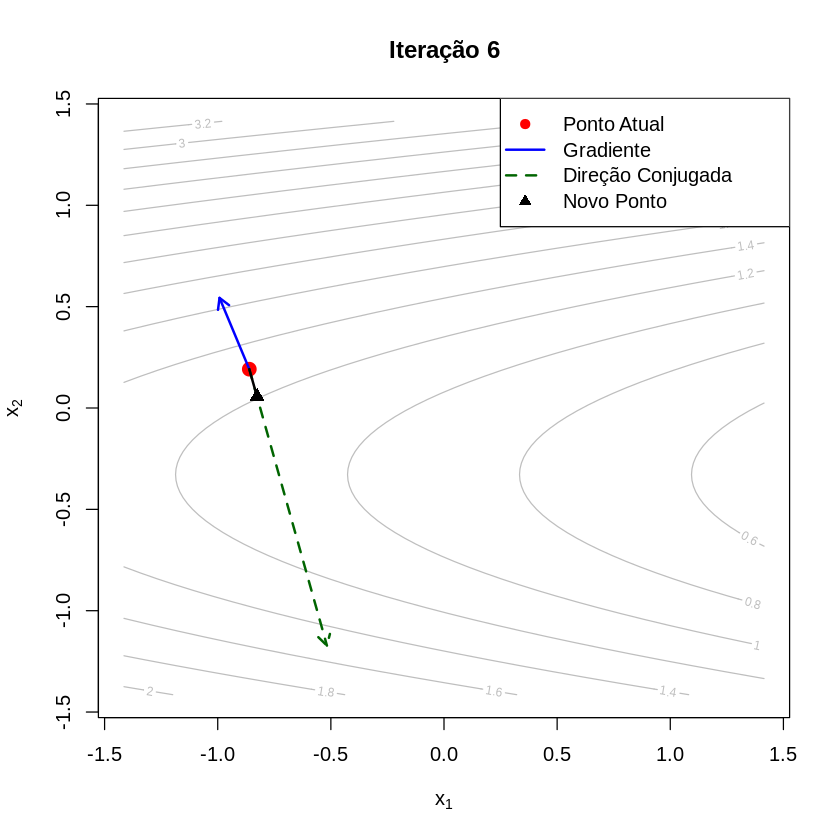

7 	

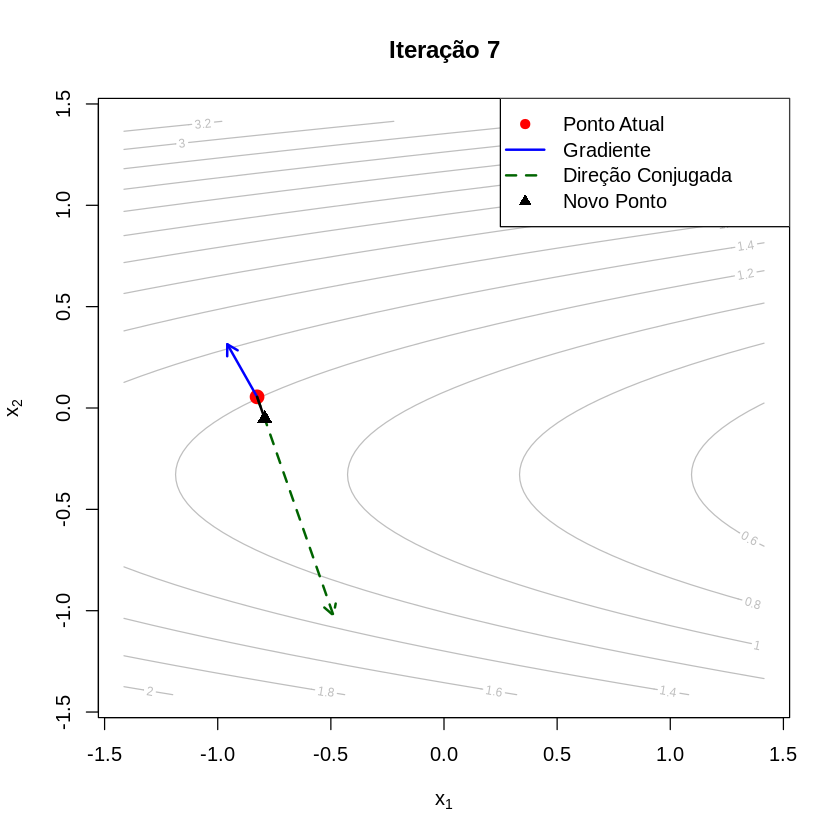

8 	

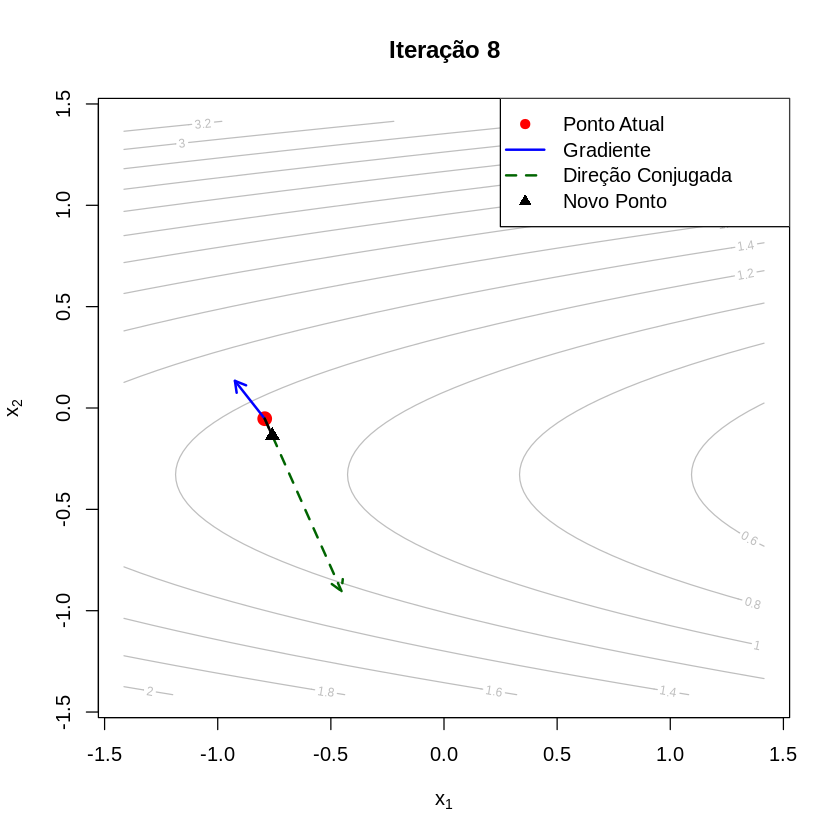

9 	

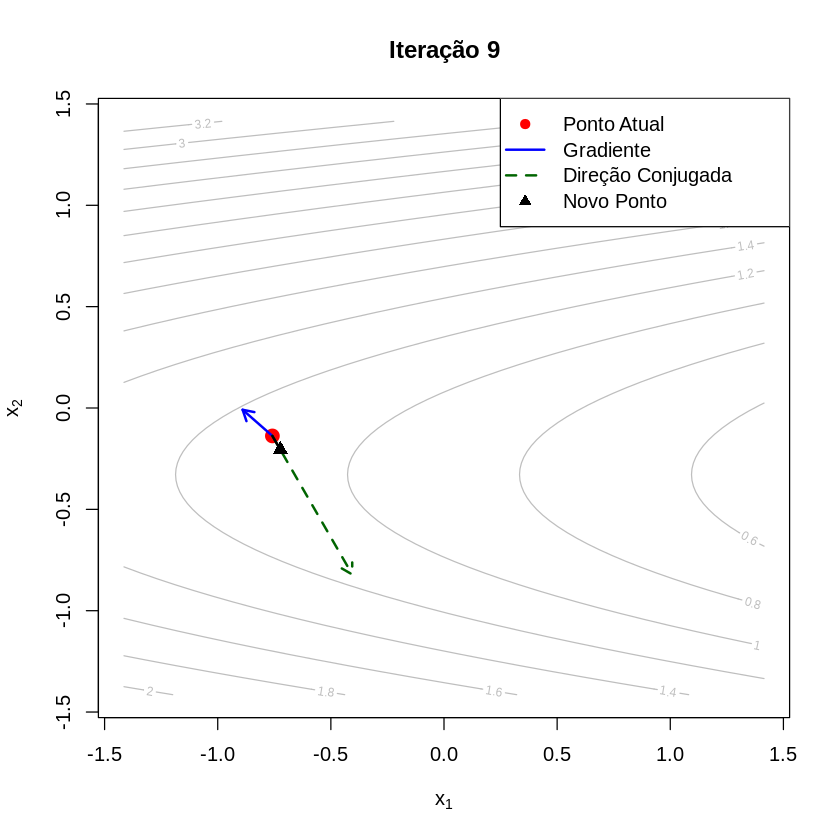

10 	

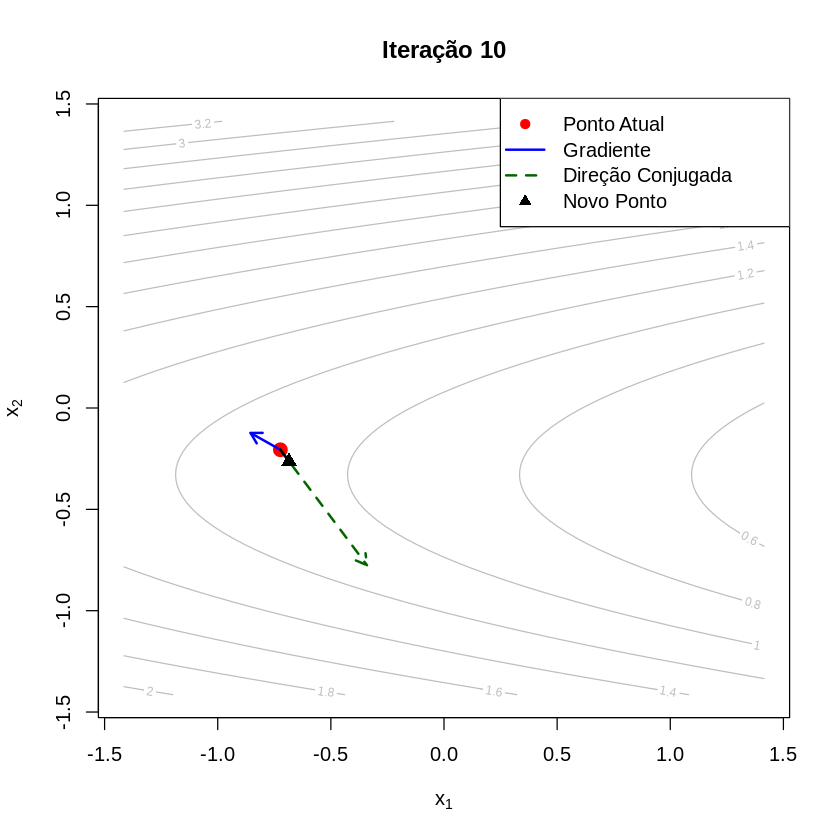

11 	

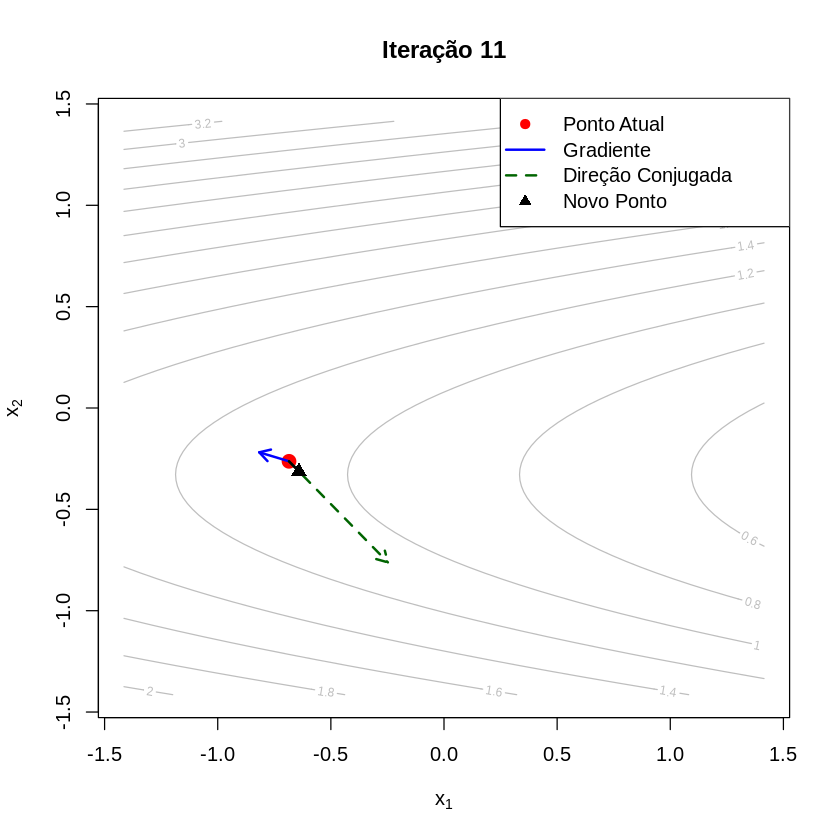

12 	

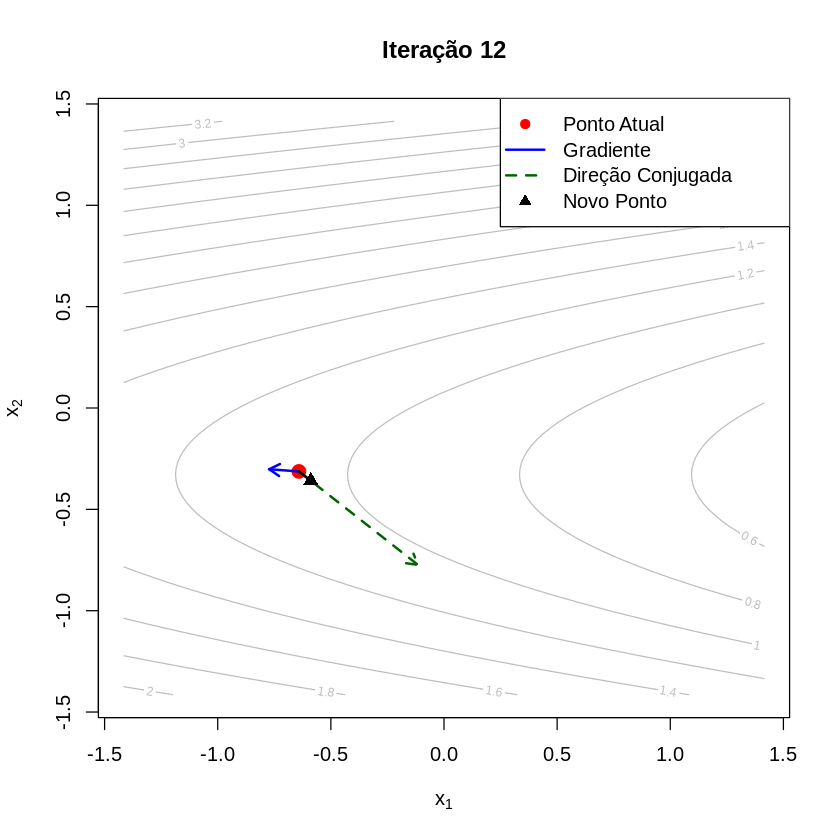

13 	

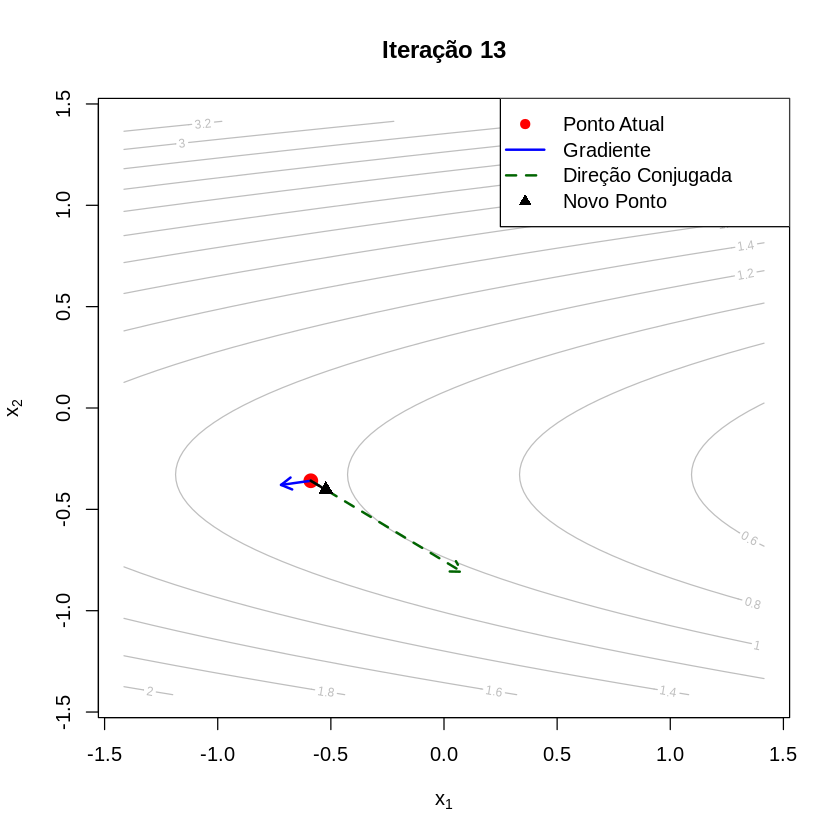

14 	

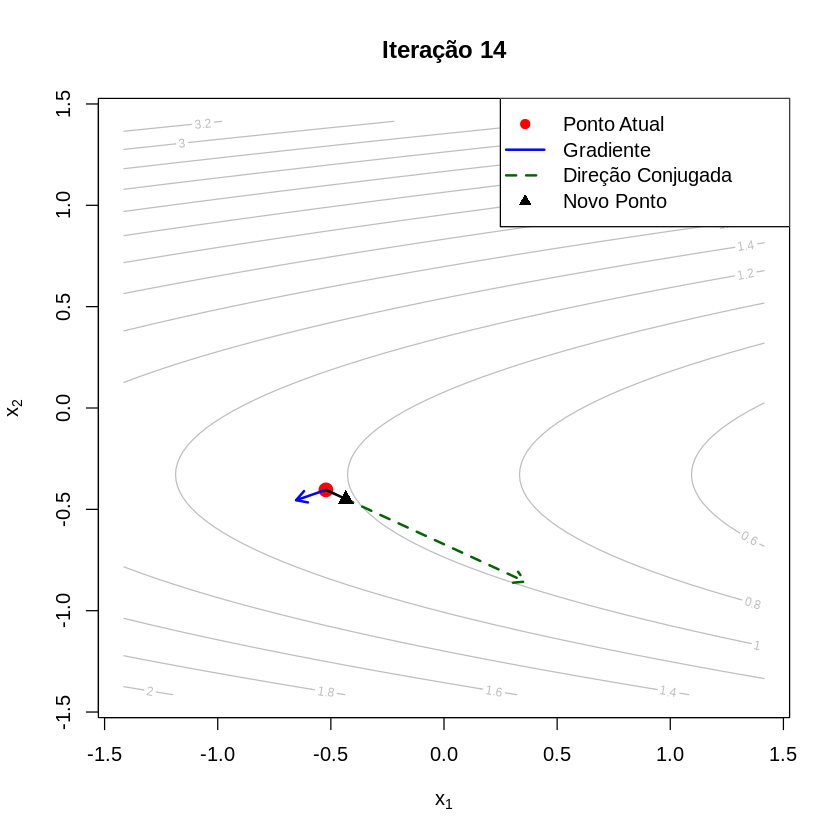

15 	

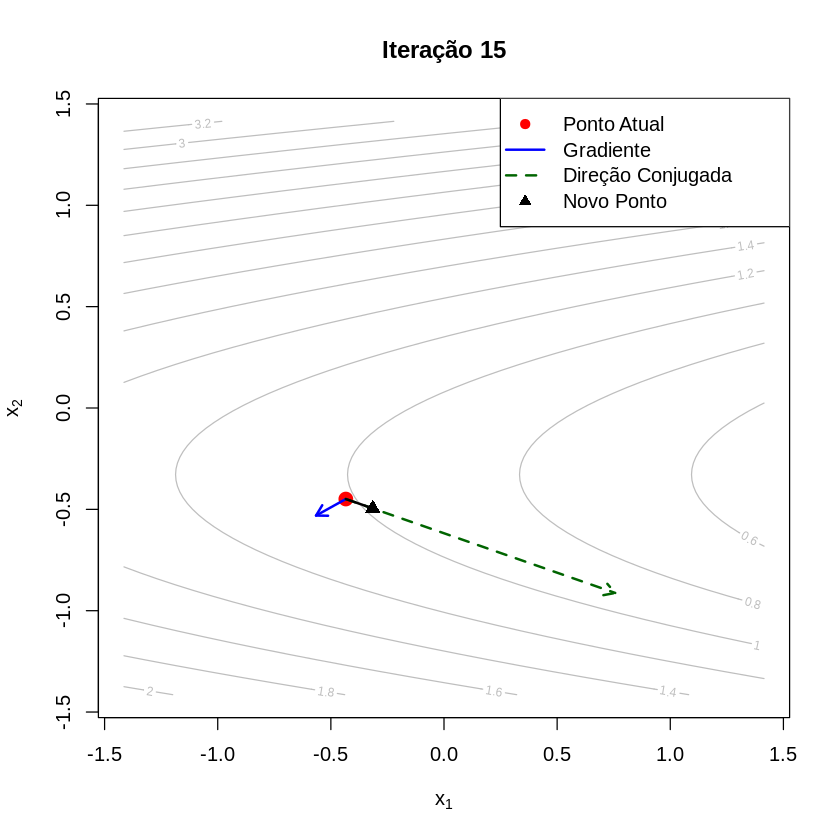

16 	

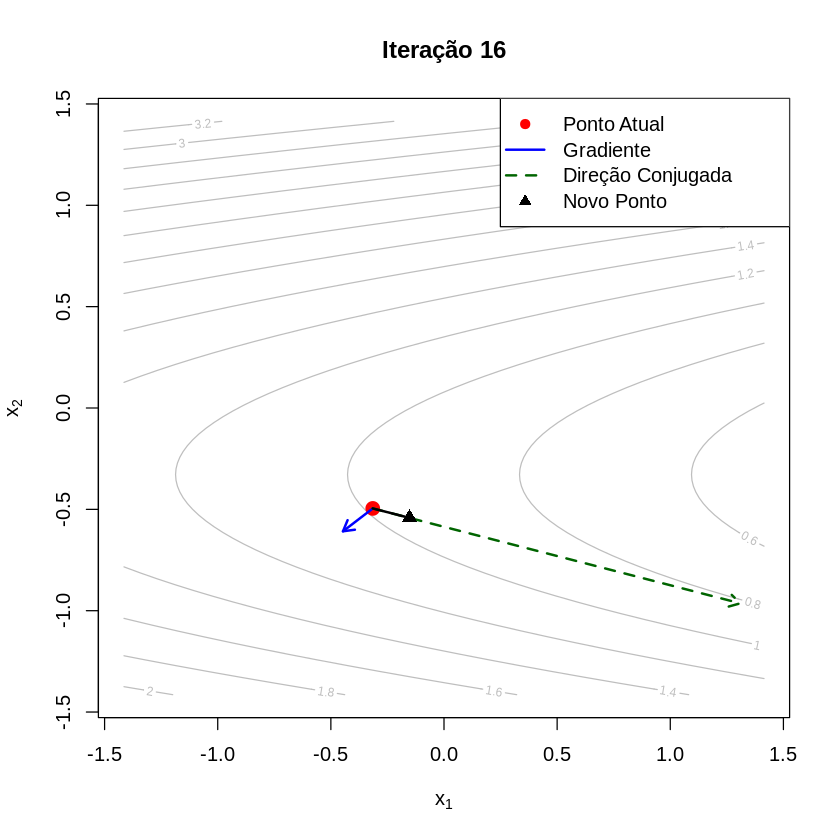

17 	

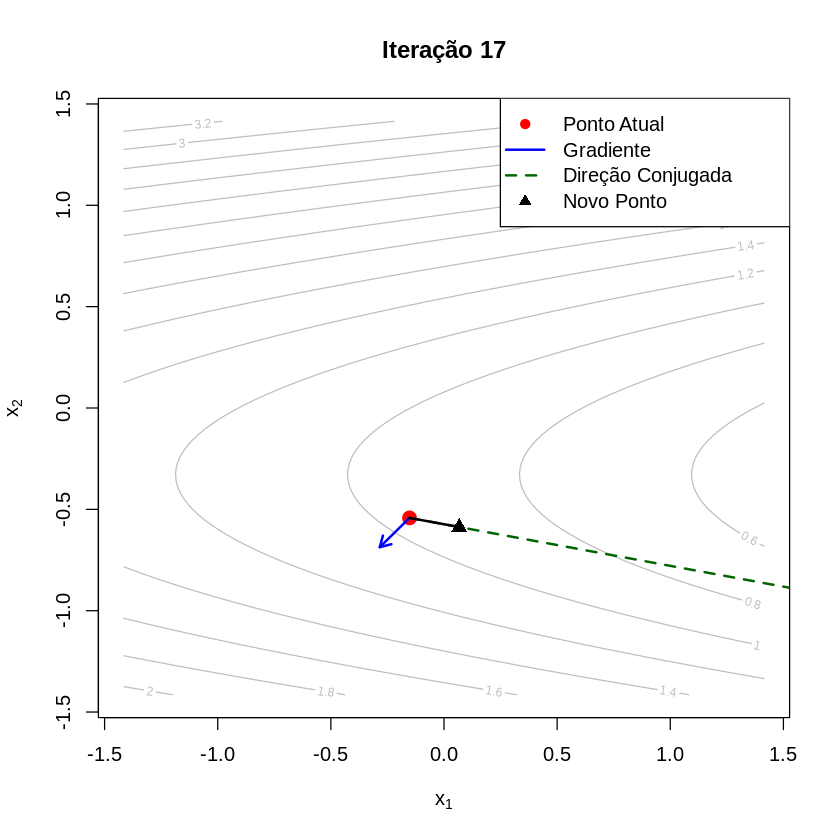

18 	

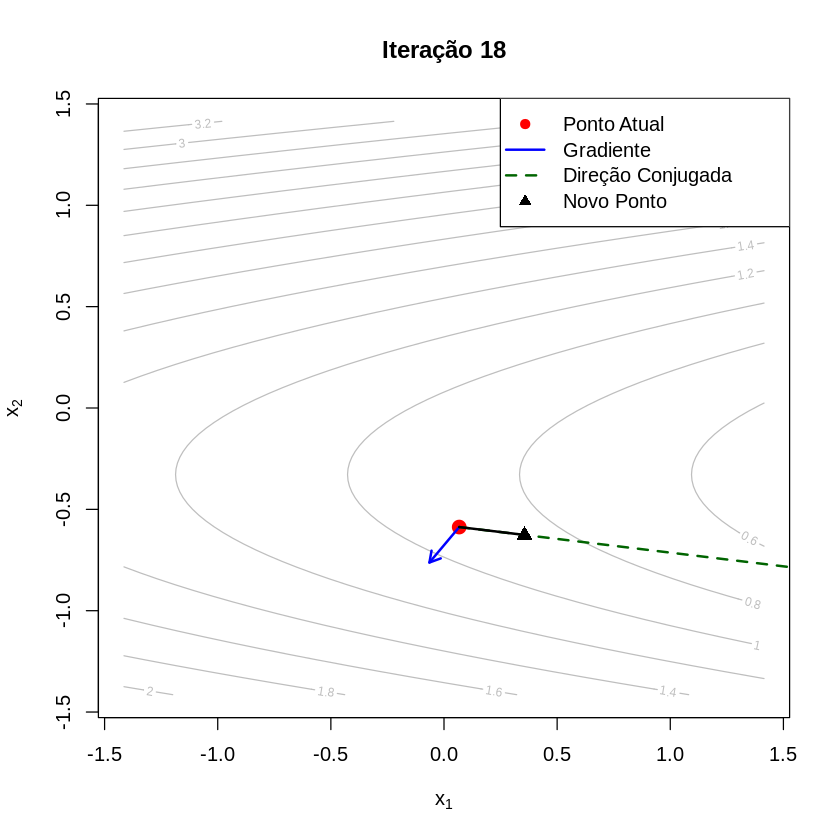

19 	

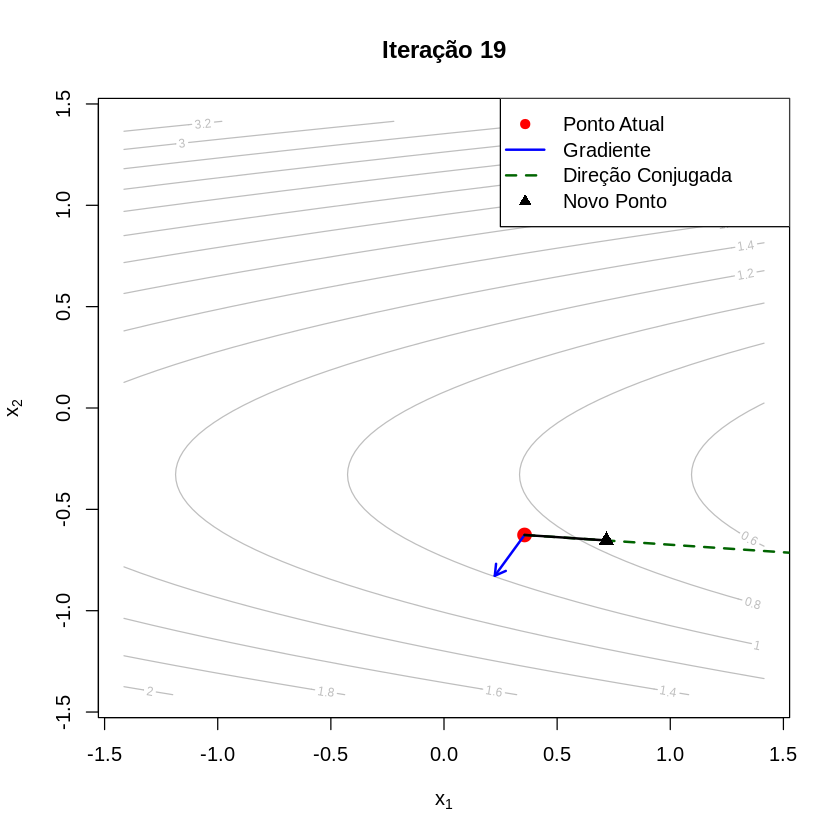

20 	

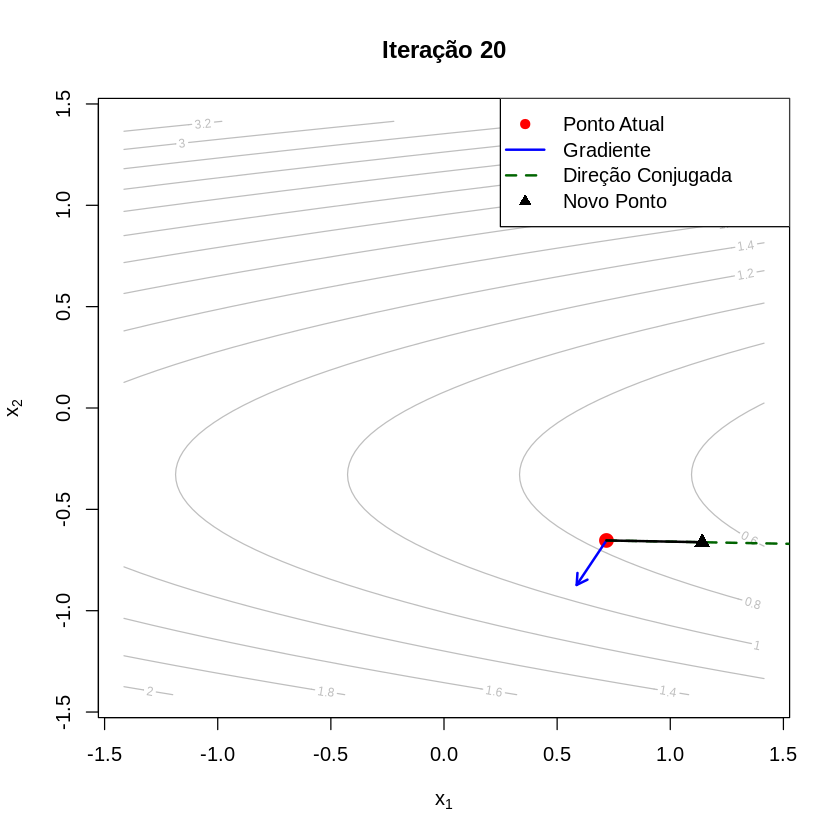

21 	

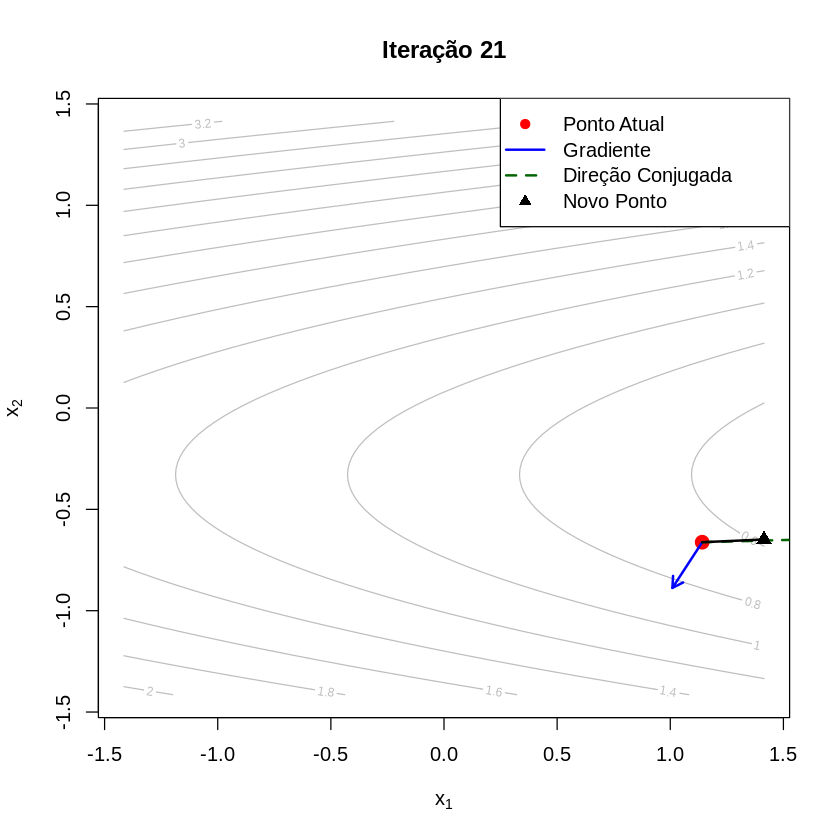

22 	

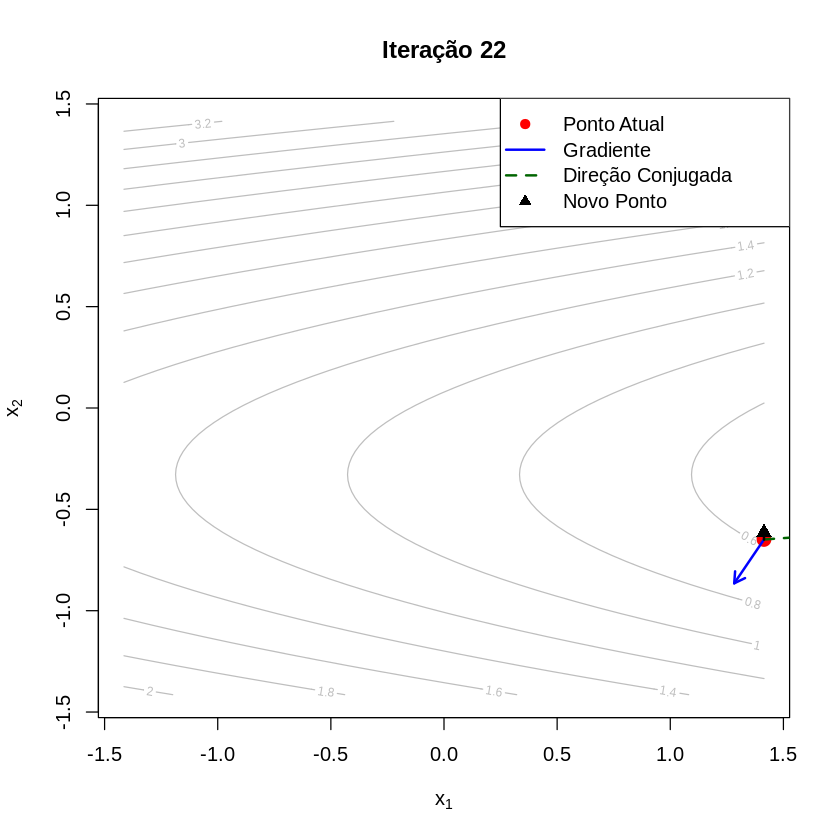

23 	

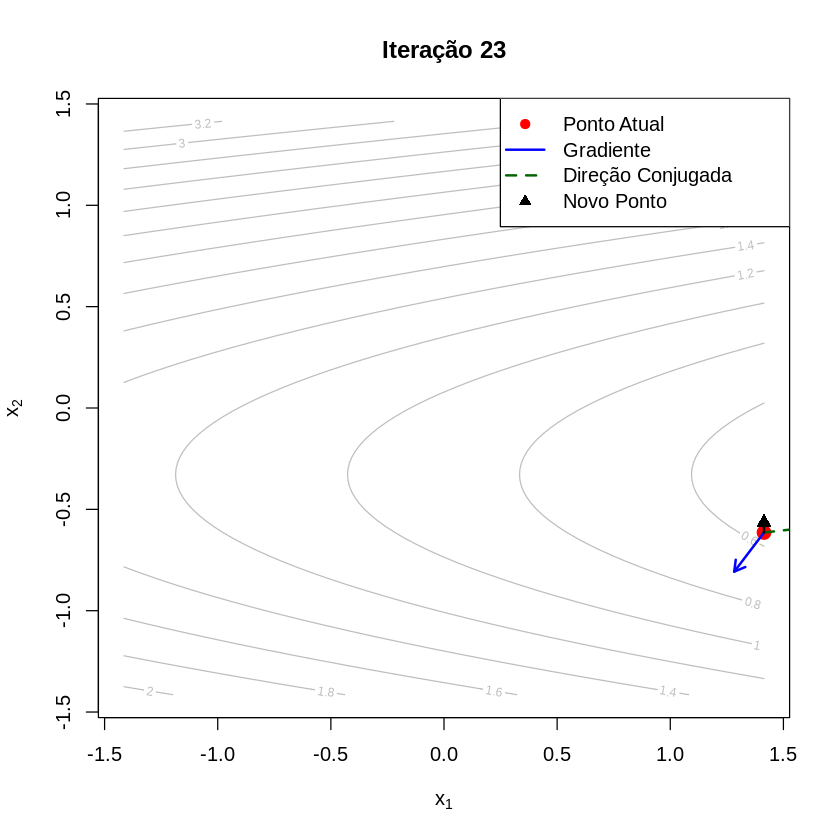

24 	

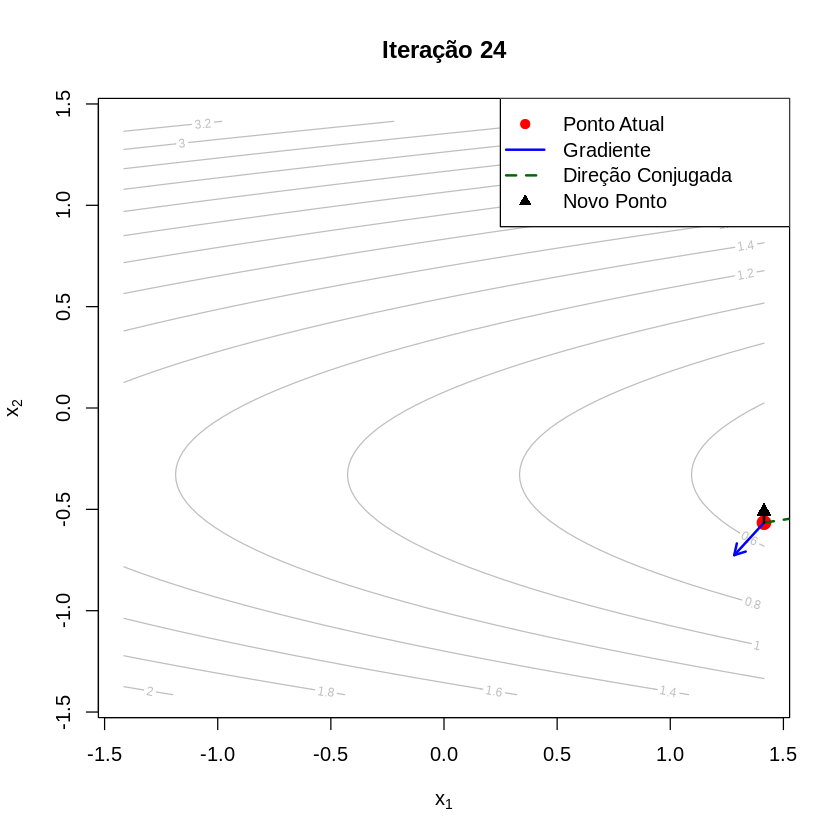

25 	

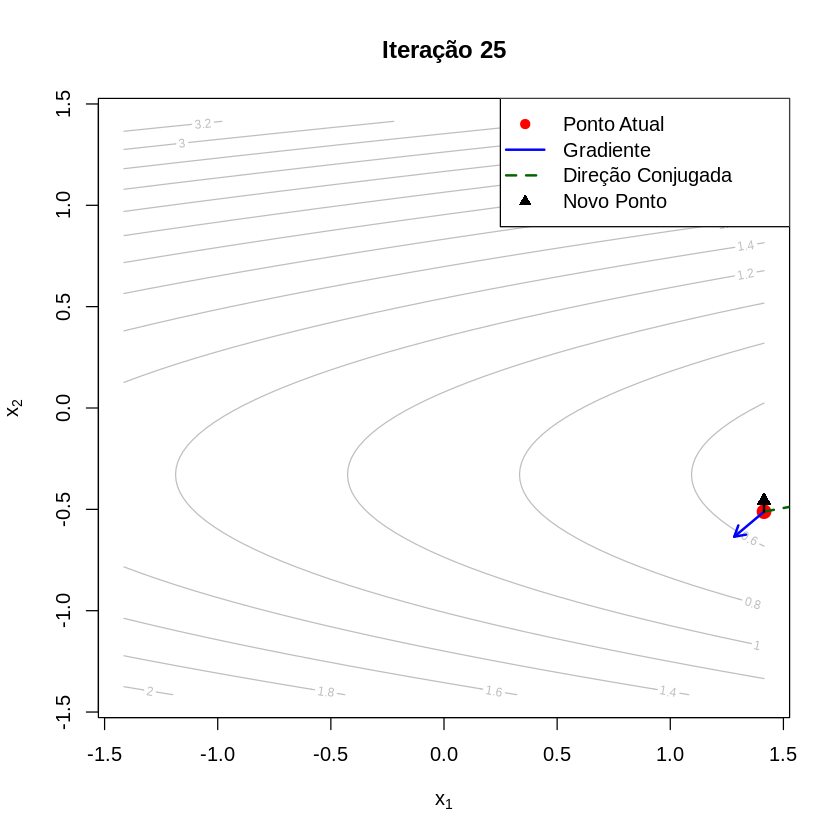

26 	

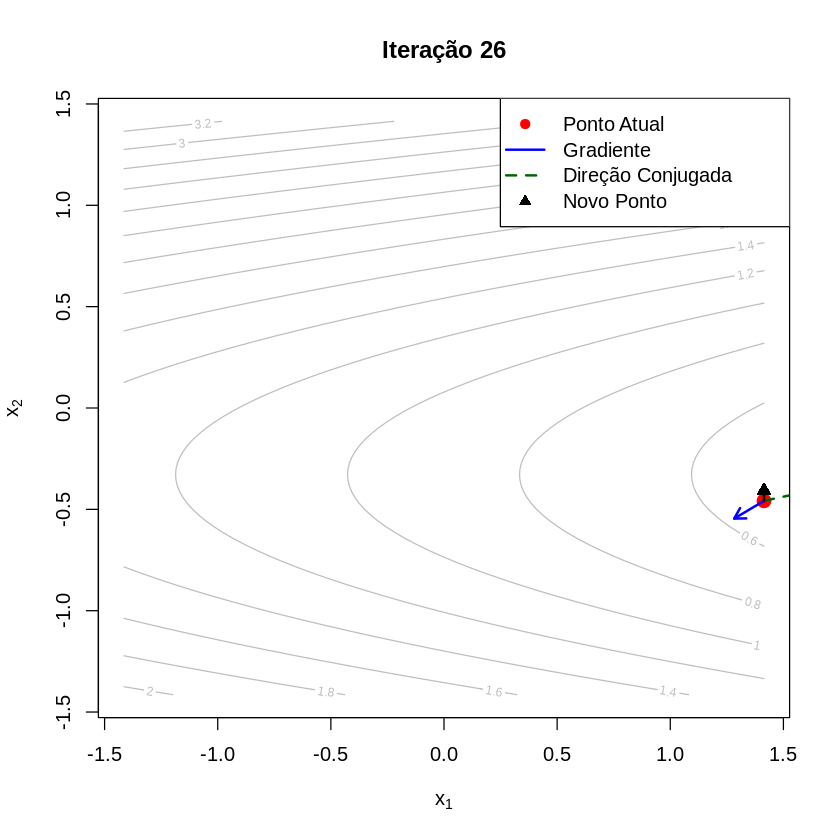

27 	

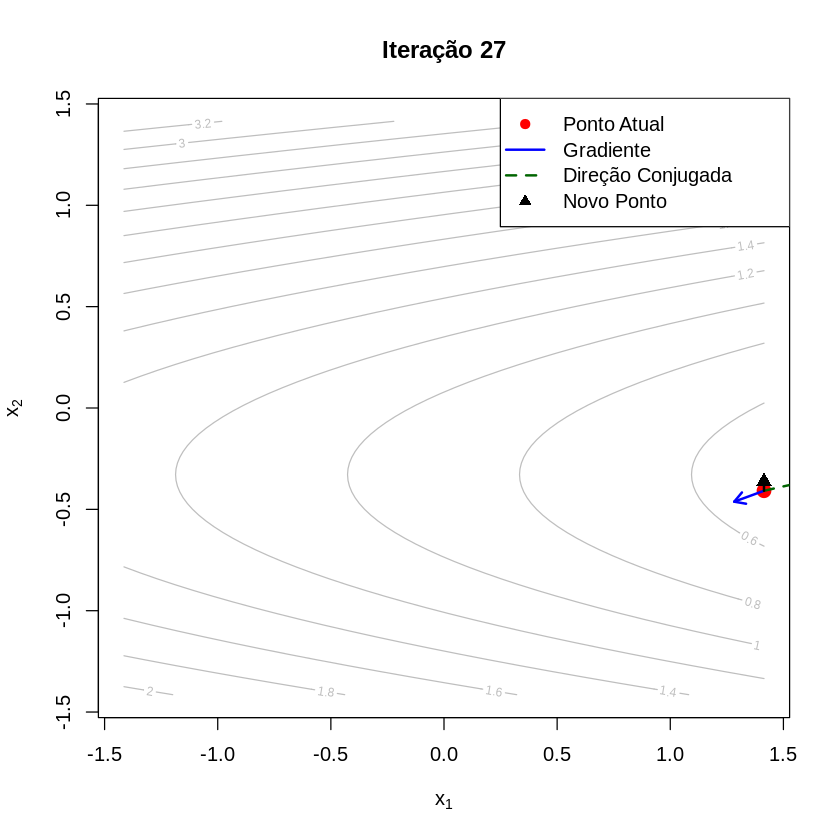

28 	

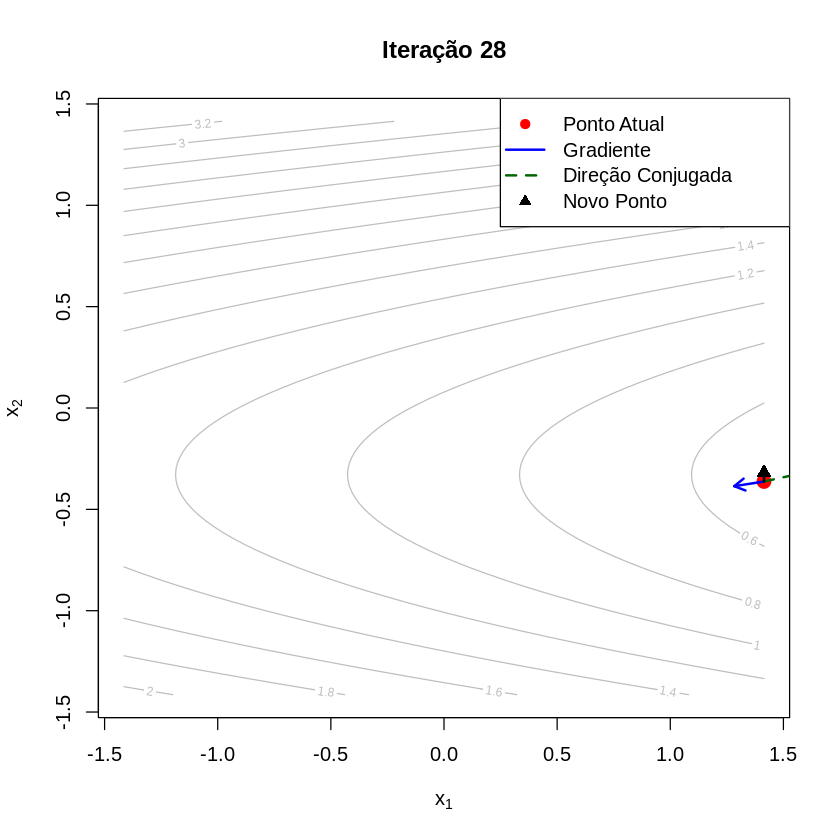

29 	

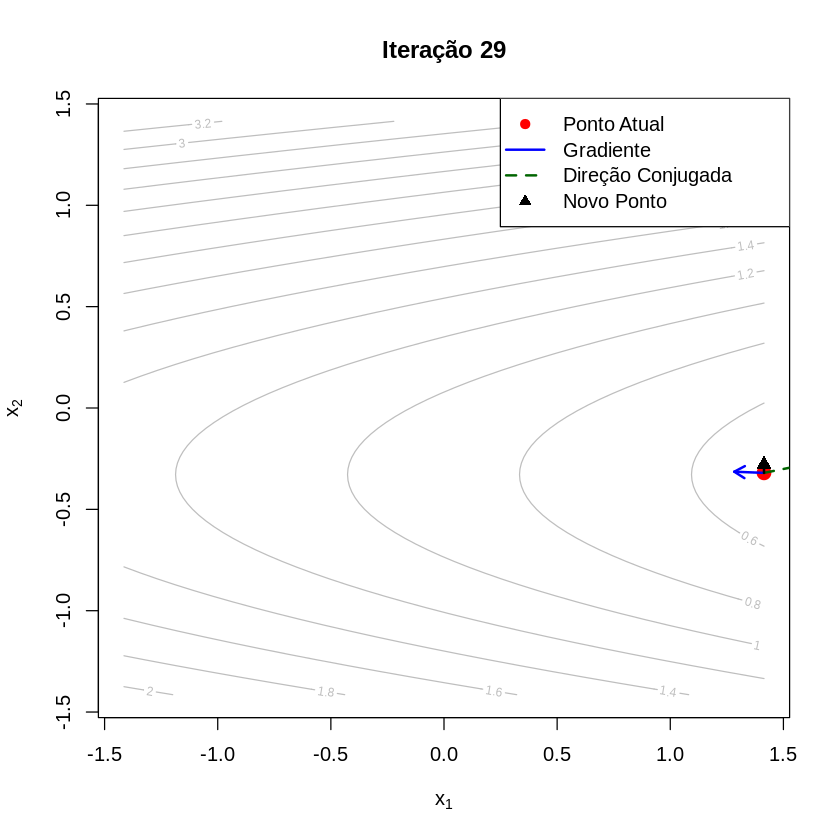

30 	

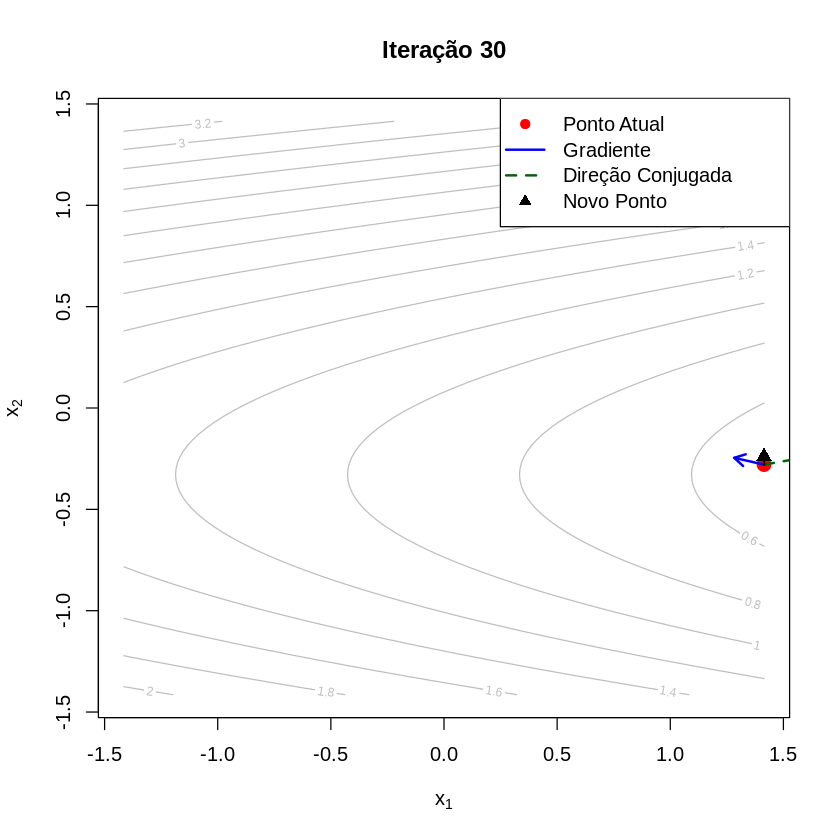

31 	

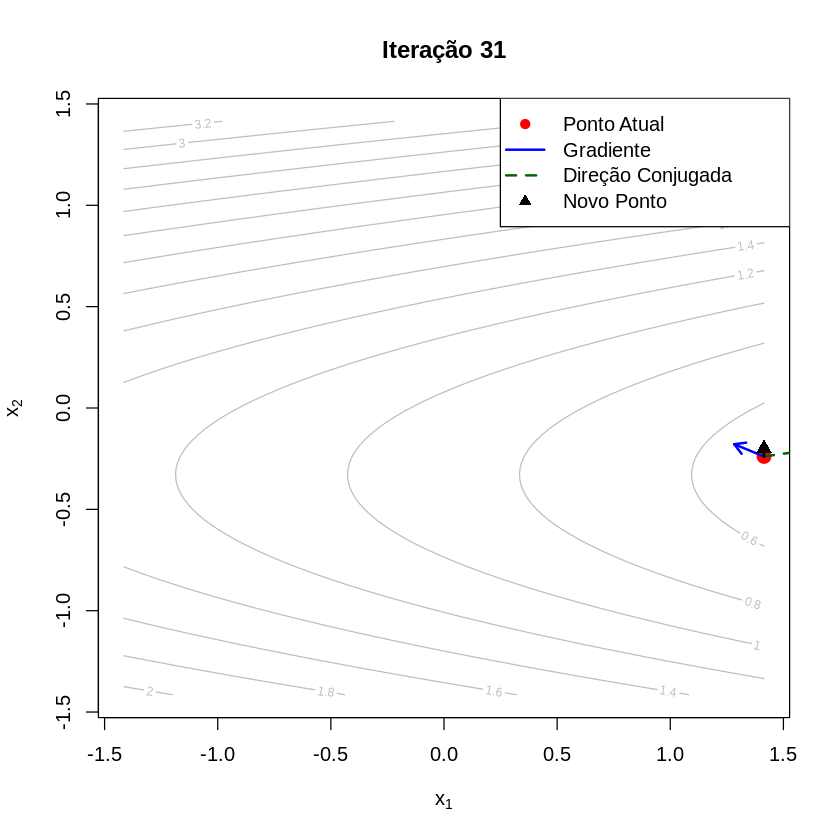

32 	

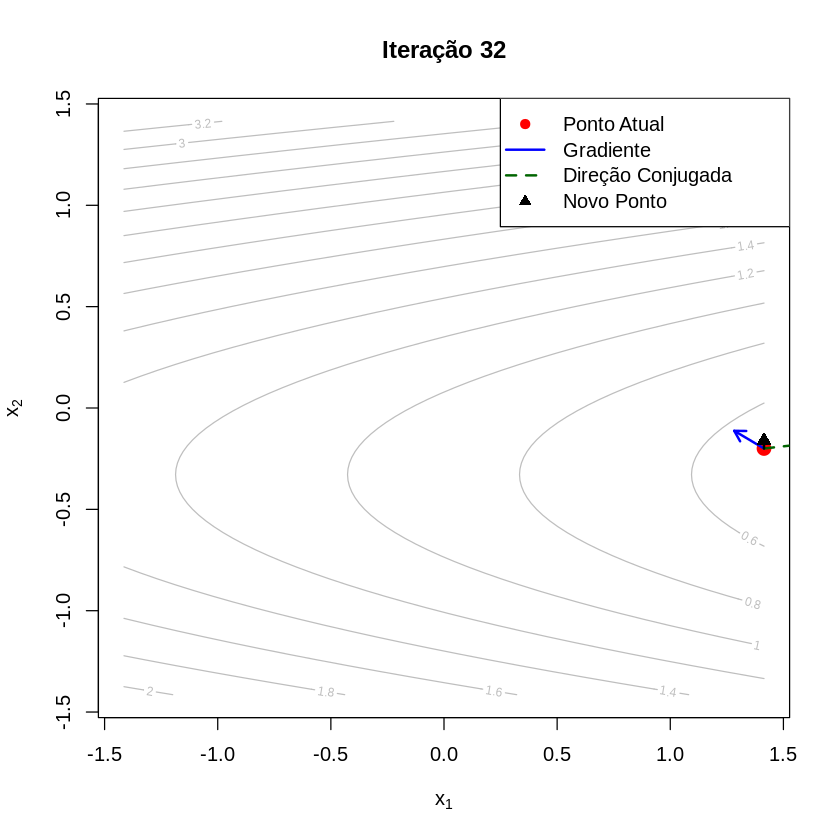

33 	

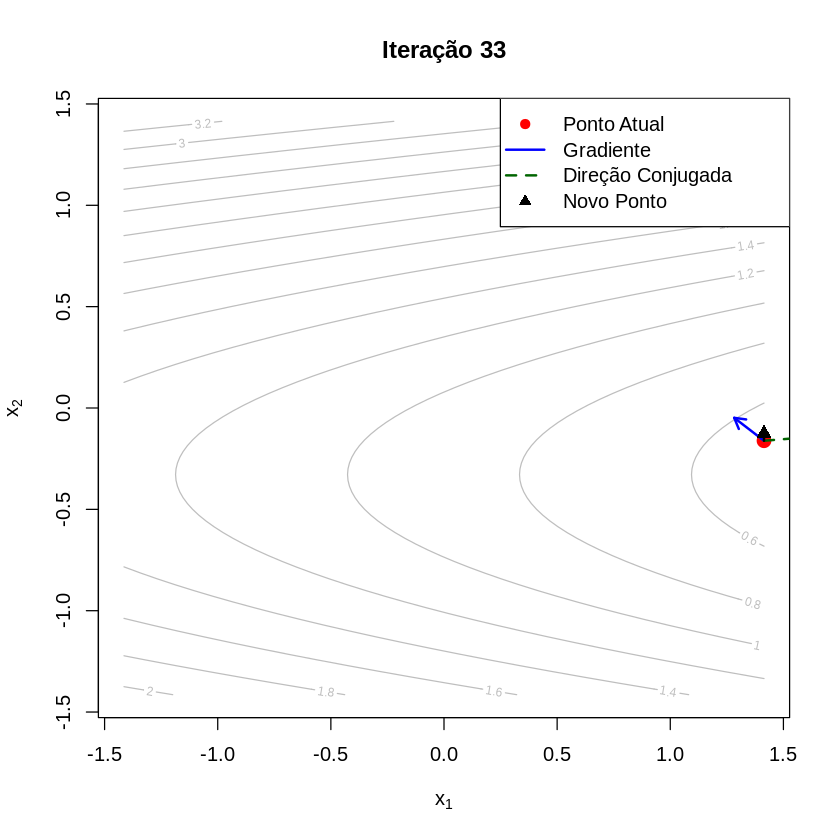

34 	

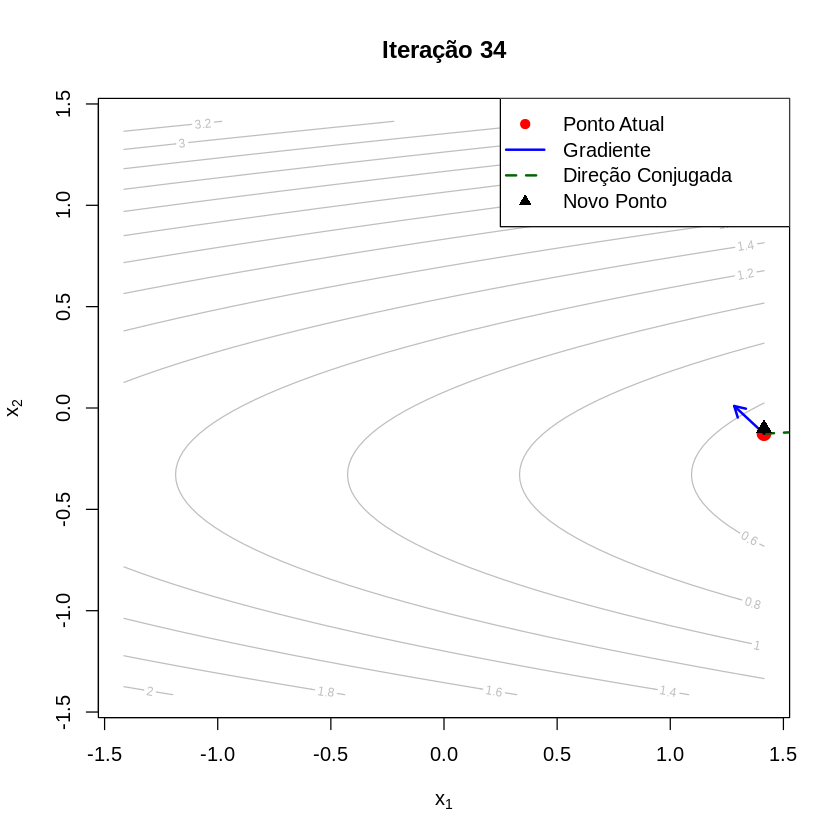

35 	

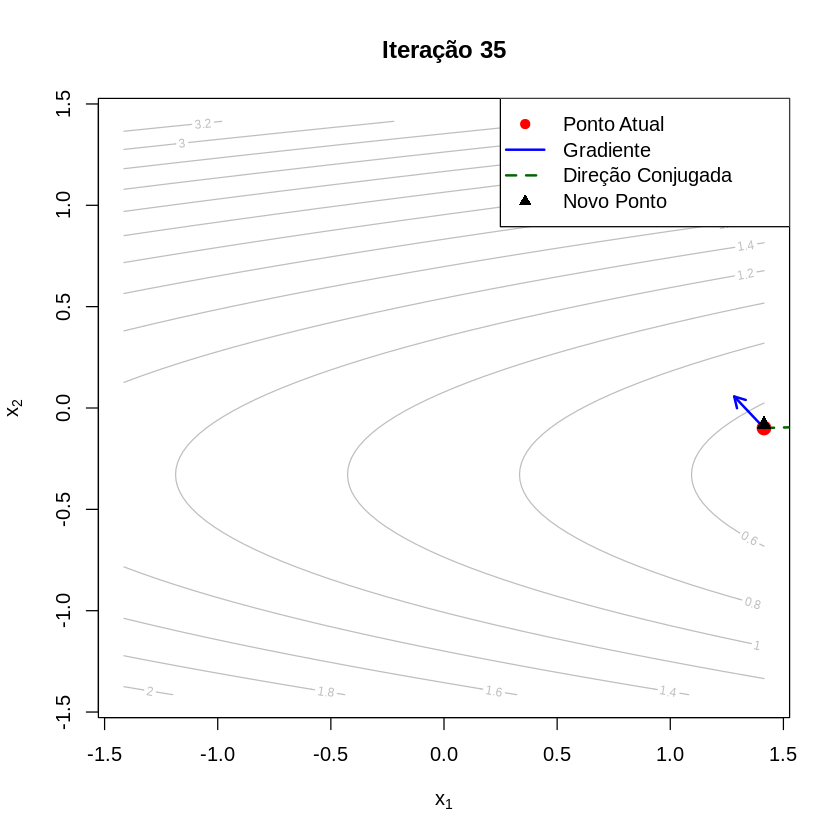

36 	

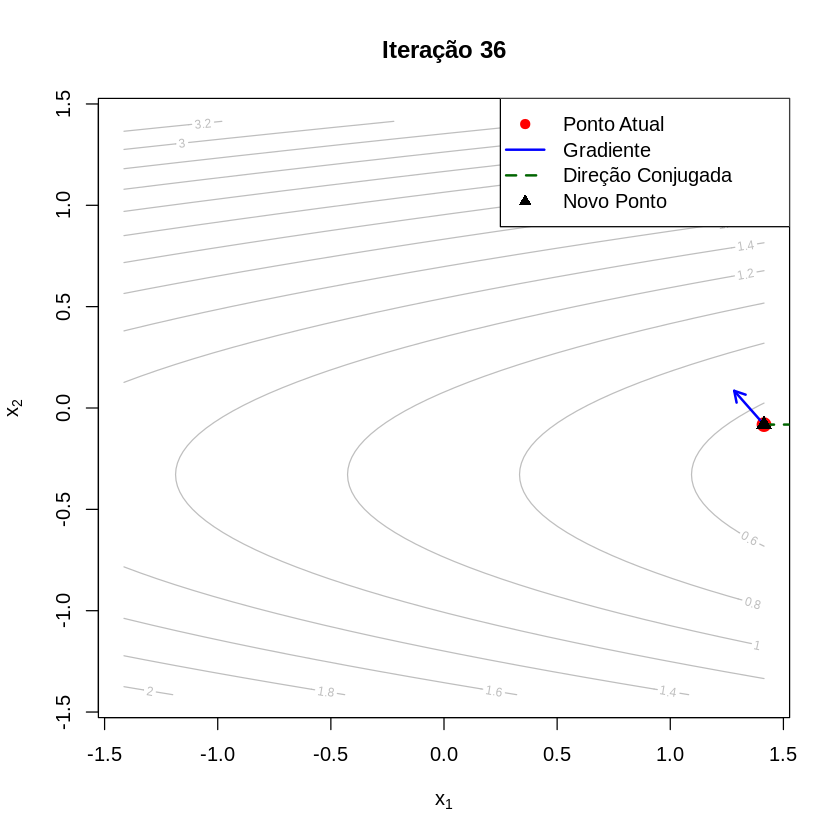

37 	

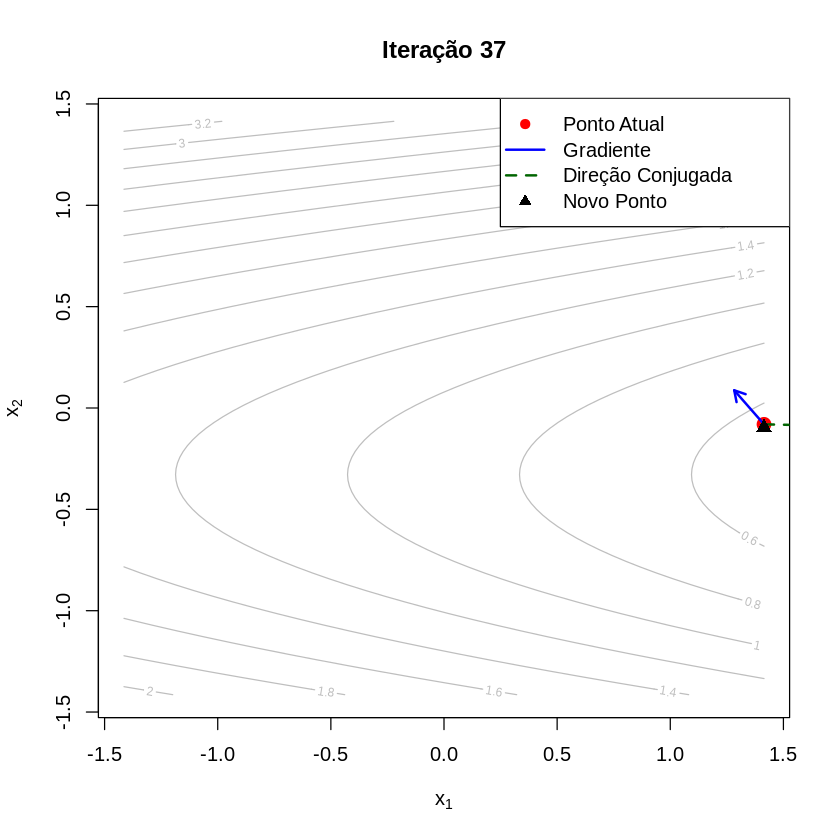

38 	

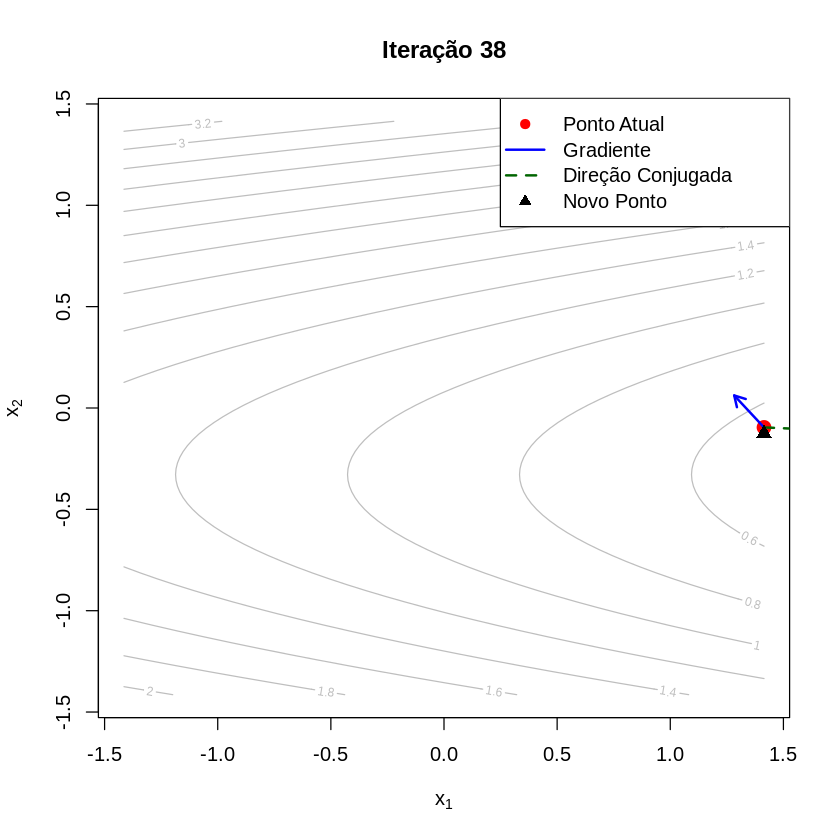

39 	

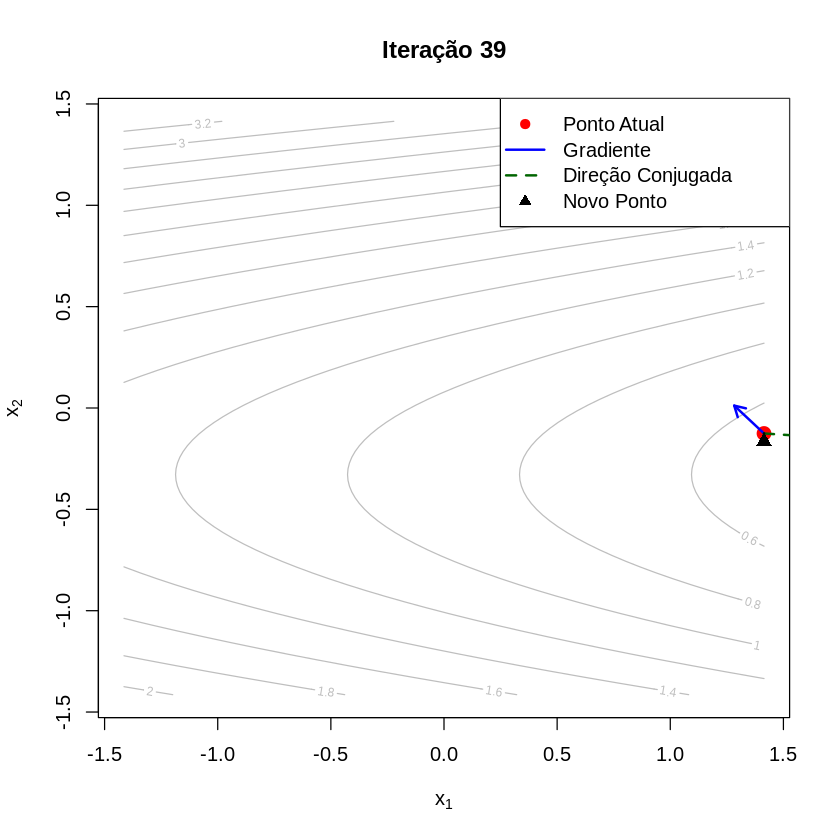

40 	

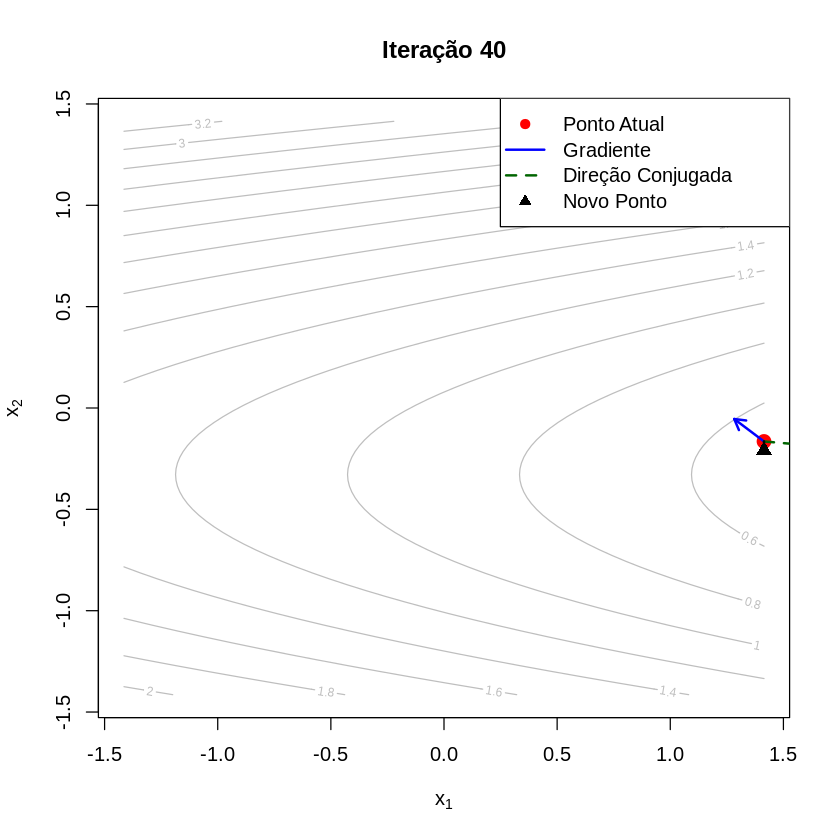

In [19]:
# @title
for(k in 1:max_iter){

  #Desenhar contono
  contour(
    x1_seq,
    x2_seq,
    z,

    nlevels = 10,

    col = "gray",

    xlab = expression(x[1]),
    ylab = expression(x[2]),

    main = paste(
      "Iteração",
      k
    )
  )

  #Ponto atual
  points(
    x[1],
    x[2],

    pch = 19,
    col = "red",
    cex = 1.5
  )

  #Gradiente
  arrows(
    x[1],
    x[2],

    x[1] + g[1]*0.5,
    x[2] + g[2]*0.5,

    col = "blue",
    lwd = 2,
    length = 0.1
  )

  #Direção conjugada
  arrows(
    x[1],
    x[2],

    x[1] + d[1]*0.5,
    x[2] + d[2]*0.5,

    col = "darkgreen",
    lty = 2,
    lwd = 2,
    length = 0.1
  )

  #Novo ponto
  x_new <- x + alpha*d

  x_new[1] <- max(
    -lim,
    min(lim,x_new[1])
  )

  x_new[2] <- max(
    -lim,
    min(lim,x_new[2])
  )

  points(
    x_new[1],
    x_new[2],

    pch = 17,
    col = "black",
    cex = 1.3
  )

  #Trajetória
  segments(
    x[1],
    x[2],

    x_new[1],
    x_new[2],

    lwd = 2,
    col = "black"
  )

  #Legenda
  legend(
    "topright",

  legend = c(
      "Ponto Atual",
      "Gradiente",
      "Direção Conjugada",
      "Novo Ponto"
    ),

  col = c(
      "red",
      "blue",
      "darkgreen",
      "black"
    ),

  pch = c(19, NA, NA, 17
    ),

  lwd = c(NA, 2, 2, NA
    ),

  lty = c(1, 1, 2, 1)
  )

  #Novo gradiente
  g_new <- grad(x_new)

  #Erro baseado no gradiente
  erro.g <- sqrt(sum(g_new^2))
  #Erro baseado no ponto
  erro.x <- sqrt(sum((x_new - x)^2))
  #Erro baseado no valor da função
  erro.f <- sqrt(sum((f(x_new) - f(x))^2))

  #Salvando informações
  historico <- rbind(
  historico,
  data.frame(
    iter = k,
    x1 = x[1],
    x2 = x[2],
    f = f(x),
    grad_norm = sqrt(sum(g^2)),
    erro.g = erro.g,
    erro.x = erro.x,
    erro.f = erro.f
  )
  )

  #Critério de parada
  if(erro.g < tol | erro.x < tol | erro.f < tol) break

  #Fletcher-Reeves
  beta <- sum(g_new^2) / sum(g^2)

  #Atualizar direção
  d <- -g_new + beta*d

  #Atualizar variáveis
  x <- x_new
  g <- g_new

  cat(k,"\t")

}


O histórico de todas essas iterações é:

In [20]:
historico

iter,x1,x2,f,grad_norm,erro.g,erro.x,erro.f
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1.00000000,1.00000000,2.3445480,1.8157955,1.6957014,0.090789774,0.1593998565
2,-0.98684315,0.91016860,2.1851481,1.6957014,1.4795605,0.163960369,0.2602592513
3,-0.96221225,0.74806887,1.9248889,1.4795605,1.2193956,0.198785969,0.2680426158
4,-0.93030342,0.55186060,1.6568463,1.2193956,0.9664697,0.195926783,0.2135996741
5,-0.89547280,0.35905465,1.4432466,0.9664697,0.7509261,0.171238388,0.1461004030
6,-0.86043589,0.19143902,1.2971462,0.7509261,0.5818399,0.140604442,0.0923574994
7,-0.82612741,0.05508456,1.2047887,0.5818399,0.4566078,0.112969430,0.0569701045
8,-0.79237308,-0.05272424,1.1478186,0.4566078,0.3686262,0.091576367,0.0357797626
9,-0.75842841,-0.13777710,1.1120388,0.3686262,0.3109867,0.076910900,0.0237686467


Vamos encontrar os valores de ($x_1,x_2$) para os quais cada erro foi o mínimo:

In [21]:
#Para o erro.g
historico[historico$erro.g==min(historico$erro.g),]

#Para o erro.x
historico[historico$erro.x==min(historico$erro.x),]

#Para o erro.f
historico[historico$erro.f==min(historico$erro.f),]


,iter,x1,x2,f,grad_norm,erro.g,erro.x,erro.f
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28,28,1.414214,-0.3626695,0.5164733,0.2671168,0.263394,0.04257592,0.0007303152


,iter,x1,x2,f,grad_norm,erro.g,erro.x,erro.f
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
36,36,1.414214,-0.0820228,0.5568313,0.424845,0.4264653,0.001524466,0.0005100492


,iter,x1,x2,f,grad_norm,erro.g,erro.x,erro.f
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
36,36,1.414214,-0.0820228,0.5568313,0.424845,0.4264653,0.001524466,0.0005100492


Como desejamos o menor valor de $f$, então nessas condições o valor para $k=28$ teria o menor valor.

Uma outra alternativa seria ver o menor valor de $f$ encontrado nas iterações:

In [22]:
historico[historico$f==min(historico$f),]

,iter,x1,x2,f,grad_norm,erro.g,erro.x,erro.f
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
29,29,1.414214,-0.3200936,0.515743,0.263394,0.2714889,0.04081582,0.001601075


Um melhora nesse método do Gradiente Conjugado poderia ser encontrado ao diminuirmos o tamanho do passo, aumentarmos a precisão de cada objeto e o número de iterações.